<a href="https://colab.research.google.com/github/lseidy/IA_learning/blob/main/Pokemon_Predict.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Bibliotecas utilizadas

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import zipfile
import plotly.express as ex
!pip install unidecode
from unidecode import unidecode
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

In [ ]:
caminho_zip = '/content/drive/MyDrive/MBA/Pokemon_1-8th.zip'

df = None
nome_csv_encontrado = None


with zipfile.ZipFile(caminho_zip, 'r') as zip_ref:

  list_founded = zip_ref.namelist()
  print(list_founded)
  poke = list_founded[2]

  with zip_ref.open(poke) as f:

    df = pd.read_csv(f)

['pokedex_(Update.04.20).csv', 'pokedex_(Update_04.21).csv', 'pokedex_(Update_05.20).csv']


# Avaliação Inicial do banco


### Foram removidas algumas colunas não necessarias para a realização do trabalho, como a coluna de numeração 'Unnamed: 0' e o nome dos pokemons em outros idiomas 'german_name' e 'japanese_name'.



In [ ]:
df.describe()

,Unnamed: 0,pokedex_number,generation,type_number,height_m,weight_kg,abilities_number,total_points,hp,attack,...,against_ground,against_flying,against_psychic,against_bug,against_rock,against_ghost,against_dragon,against_dark,against_steel,against_fairy
count,1028.000000,1028.000000,1028.000000,1028.000000,1028.000000,1027.000000,1028.000000,1028.000000,1028.000000,1028.000000,...,1028.000000,1028.000000,1028.000000,1028.000000,1028.000000,1028.000000,1028.000000,1028.000000,1028.000000,1028.000000
mean,513.500000,437.711089,4.034047,1.527237,1.368093,69.753749,2.284047,437.571984,69.577821,80.119650,...,1.084630,1.166342,0.979329,0.992461,1.239786,1.010700,0.975681,1.065661,0.980302,1.084874
std,296.902341,259.366480,2.234937,0.499501,3.380126,129.221230,0.794981,121.664910,26.385849,32.372321,...,0.784937,0.593030,0.499146,0.598301,0.699156,0.558533,0.377549,0.451054,0.503434,0.527743
min,0.000000,1.000000,1.000000,1.000000,0.100000,0.100000,0.000000,175.000000,1.000000,5.000000,...,0.000000,0.250000,0.000000,0.000000,0.250000,0.000000,0.000000,0.250000,0.000000,0.000000
25%,256.750000,213.750000,2.000000,1.000000,0.600000,8.800000,2.000000,330.000000,50.000000,55.000000,...,0.500000,1.000000,1.000000,0.500000,1.000000,1.000000,1.000000,1.000000,0.500000,1.000000
50%,513.500000,433.500000,4.000000,2.000000,1.000000,28.500000,2.000000,455.000000,66.500000,76.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
75%,770.250000,663.250000,6.000000,2.000000,1.500000,69.100000,3.000000,510.000000,80.000000,100.000000,...,1.625000,1.000000,1.000000,1.000000,2.000000,1.000000,1.000000,1.000000,1.000000,1.000000
max,1027.000000,890.000000,8.000000,2.000000,100.000000,999.900000,3.000000,1125.000000,255.000000,190.000000,...,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,2.000000,4.000000,4.000000,4.000000


In [ ]:
print(df.select_dtypes(exclude=['number']).head())

            name german_name        japanese_name  status         species  \
0      Bulbasaur     Bisasam  フシギダネ (Fushigidane)  Normal    Seed Pokémon   
1        Ivysaur   Bisaknosp   フシギソウ (Fushigisou)  Normal    Seed Pokémon   
2       Venusaur    Bisaflor  フシギバナ (Fushigibana)  Normal    Seed Pokémon   
3  Mega Venusaur    Bisaflor  フシギバナ (Fushigibana)  Normal    Seed Pokémon   
4     Charmander    Glumanda      ヒトカゲ (Hitokage)  Normal  Lizard Pokémon   

  type_1  type_2  ability_1 ability_2 ability_hidden  growth_rate egg_type_1  \
0  Grass  Poison   Overgrow       NaN    Chlorophyll  Medium Slow      Grass   
1  Grass  Poison   Overgrow       NaN    Chlorophyll  Medium Slow      Grass   
2  Grass  Poison   Overgrow       NaN    Chlorophyll  Medium Slow      Grass   
3  Grass  Poison  Thick Fat       NaN            NaN  Medium Slow      Grass   
4   Fire     NaN      Blaze       NaN    Solar Power  Medium Slow     Dragon   

  egg_type_2  
0    Monster  
1    Monster  
2    Monste

In [ ]:
drop_columns = ['Unnamed: 0','german_name', 'japanese_name', 'percentage_male']

In [ ]:
for column in drop_columns:
  df = df.drop(column,axis=1)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1028 entries, 0 to 1027
Data columns (total 47 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   pokedex_number    1028 non-null   int64  
 1   name              1028 non-null   object 
 2   generation        1028 non-null   int64  
 3   status            1028 non-null   object 
 4   species           1028 non-null   object 
 5   type_number       1028 non-null   int64  
 6   type_1            1028 non-null   object 
 7   type_2            542 non-null    object 
 8   height_m          1028 non-null   float64
 9   weight_kg         1027 non-null   float64
 10  abilities_number  1028 non-null   int64  
 11  ability_1         1025 non-null   object 
 12  ability_2         513 non-null    object 
 13  ability_hidden    810 non-null    object 
 14  total_points      1028 non-null   float64
 15  hp                1028 non-null   float64
 16  attack            1028 non-null   float64


# Tratamento de valores inconsistentes

Não havia duplicatas, valores nulos categoricos foram substituidos por "Vazio" e valores nulos numéricos foram substituidos pela média. As escolhas se deram por haver poucos valores nulos.

O Target é a coluna Type_1, o tipo primário dos pokemons (Agua,Fogo,Psiquico...)

Foram feitas a correlação entre as colunas numéricas, bem como o describe do banco de dados foi visto. Alem disso histograma, boxplot e outras visualizações foram feitas para indentificar os padrões e outliers do banco.

In [ ]:
print(df['type_1'].value_counts())

type_1
Water       134
Normal      115
Grass        91
Bug          81
Psychic      76
Fire         65
Electric     61
Rock         60
Dark         44
Ground       41
Ghost        41
Dragon       40
Poison       39
Fighting     38
Ice          36
Steel        36
Fairy        22
Flying        8
Name: count, dtype: int64


In [ ]:
def clean(texto):
    if not isinstance(texto, str):
        return texto

    texto_limpo = unidecode(texto)
    texto_limpo = texto_limpo.title()

    return texto_limpo

colunas_texto = df.select_dtypes(include=['object']).columns

df[colunas_texto] = df[colunas_texto].applymap(clean)

print(df.head())

   pokedex_number           name  generation  status         species  \
0               1      Bulbasaur           1  Normal    Seed Pokemon   
1               2        Ivysaur           1  Normal    Seed Pokemon   
2               3       Venusaur           1  Normal    Seed Pokemon   
3               3  Mega Venusaur           1  Normal    Seed Pokemon   
4               4     Charmander           1  Normal  Lizard Pokemon   

   type_number type_1  type_2  height_m  weight_kg  ...  against_ground  \
0            2  Grass  Poison       0.7        6.9  ...             1.0   
1            2  Grass  Poison       1.0       13.0  ...             1.0   
2            2  Grass  Poison       2.0      100.0  ...             1.0   
3            2  Grass  Poison       2.4      155.5  ...             1.0   
4            1   Fire     NaN       0.6        8.5  ...             2.0   

  against_flying against_psychic against_bug  against_rock  against_ghost  \
0            2.0             2.0       

/tmp/ipython-input-2510108700.py:12: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df[colunas_texto] = df[colunas_texto].applymap(clean)


In [ ]:
"""def corrigir_nomes(texto_original):
    palavras = texto_original.split()

    if len(palavras) == 3:
        novas_palavras = palavras[1:]
        return ' '.join(novas_palavras)
    else:
        return texto_original

df['species'] = df['species'].apply(corrigir_nomes)

print(df)
"""

"def corrigir_nomes(texto_original):\n    palavras = texto_original.split()\n\n    if len(palavras) == 3:\n        novas_palavras = palavras[1:]\n        return ' '.join(novas_palavras)\n    else:\n        return texto_original\n\ndf['species'] = df['species'].apply(corrigir_nomes)\n\nprint(df)\n"

In [ ]:
"""count = df['species'].value_counts()

especies_raras = count[count == 1].index

df_resultado = df[df['species'].isin(especies_raras)]
df_resultado.head(30)
"""

"count = df['species'].value_counts()\n\nespecies_raras = count[count == 1].index\n\ndf_resultado = df[df['species'].isin(especies_raras)]\ndf_resultado.head(30)\n"

In [ ]:
#print(df[df['species'] == 'Warrior Pokemon'])
"""df['species'] = df['species'].replace('Cobra Pokemon', 'Snake Pokemon')
df['species'] = df['species'].replace('Bug Pokemon', 'Worm Pokemon')
df['species'] = df['species'].replace('Legendary Pokemon', 'Dog Pokemon')
df['species'] = df['species'].replace('Lingering Pokemon', 'Lizard Pokemon')
df['species'] = df['species'].replace('Caretaker Pokemon', 'Lizard Pokemon')
df['species'] = df['species'].replace('Kicking Pokemon', 'Warrior Pokemon')
df['species'] = df['species'].replace('Scuffle Pokemon', 'Warrior Pokemon')
df['species'] = df['species'].replace('Handstand Pokemon', 'Warrior Pokemon')
df['species'] = df['species'].replace('Grudge Pokemon', 'Rock Pokemon')
df['species'] = df['species'].replace('Alloy Pokemon', 'Dragon Pokemon')
df['species'] = df['species'].replace('Punching Pokemon', 'Warrior Pokemon')
df['species'] = df['species'].replace('Mysterious Pokemon', 'Star Pokemon')
df['species'] = df['species'].replace('Viking Pokemon', 'Cat Pokemon')
df['species'] = df['species'].replace('Viking Pokemon', 'Cat Pokemon')
df['species'] = df['species'].replace('Spit Pokemon', 'Spider Pokemon')
df['species'] = df['species'].replace('Freeze Pokemon', 'Legendary Pokemon')
df['species'] = df['species'].replace('Species Pokemon', 'Legendary Pokemon')
df['species'] = df['species'].replace('Thunder Pokemon', 'Legendary Pokemon')
df['species'] = df['species'].replace('Aurora Pokemon', 'Legendary Pokemon')
df['species'] = df['species'].replace('Diving Pokemon', 'Legendary Pokemon')
df['species'] = df['species'].replace('Rainbow Pokemon', 'Legendary Pokemon')
df['species'] = df['species'].replace('Travel Pokemon', 'Legendary Pokemon')
df['species'] = df['species'].replace('Hibernator Pokemon', 'Bear Pokemon')
df['species'] = df['species'].replace('Delivery Pokemon', 'Bird Pokemon')
df['species'] = df['species'].replace('Swine Pokemon', 'Elephant Pokemon')
df['species'] = df['species'].replace('Nose Pokemon', 'Elephant Pokemon')
df['species'] = df['species'].replace('Fowl Pokemon', 'Chick Pokemon')
df['species'] = df['species'].replace('TinyRaccon Pokemon', 'Raccoon Pokemon')
"""
#Vai ficar pra outro momento

"df['species'] = df['species'].replace('Cobra Pokemon', 'Snake Pokemon')\ndf['species'] = df['species'].replace('Bug Pokemon', 'Worm Pokemon')\ndf['species'] = df['species'].replace('Legendary Pokemon', 'Dog Pokemon')\ndf['species'] = df['species'].replace('Lingering Pokemon', 'Lizard Pokemon')\ndf['species'] = df['species'].replace('Caretaker Pokemon', 'Lizard Pokemon')\ndf['species'] = df['species'].replace('Kicking Pokemon', 'Warrior Pokemon')\ndf['species'] = df['species'].replace('Scuffle Pokemon', 'Warrior Pokemon')\ndf['species'] = df['species'].replace('Handstand Pokemon', 'Warrior Pokemon')\ndf['species'] = df['species'].replace('Grudge Pokemon', 'Rock Pokemon')\ndf['species'] = df['species'].replace('Alloy Pokemon', 'Dragon Pokemon')\ndf['species'] = df['species'].replace('Punching Pokemon', 'Warrior Pokemon')\ndf['species'] = df['species'].replace('Mysterious Pokemon', 'Star Pokemon')\ndf['species'] = df['species'].replace('Viking Pokemon', 'Cat Pokemon')\ndf['species'] = df

In [ ]:
df.drop_duplicates()

,pokedex_number,name,generation,status,species,type_number,type_1,type_2,height_m,weight_kg,...,against_ground,against_flying,against_psychic,against_bug,against_rock,against_ghost,against_dragon,against_dark,against_steel,against_fairy
0,1,Bulbasaur,1,Normal,Seed Pokemon,2,Grass,Poison,0.7,6.9,...,1.0,2.0,2.0,1.00,1.00,1.0,1.0,1.0,1.0,0.5
1,2,Ivysaur,1,Normal,Seed Pokemon,2,Grass,Poison,1.0,13.0,...,1.0,2.0,2.0,1.00,1.00,1.0,1.0,1.0,1.0,0.5
2,3,Venusaur,1,Normal,Seed Pokemon,2,Grass,Poison,2.0,100.0,...,1.0,2.0,2.0,1.00,1.00,1.0,1.0,1.0,1.0,0.5
3,3,Mega Venusaur,1,Normal,Seed Pokemon,2,Grass,Poison,2.4,155.5,...,1.0,2.0,2.0,1.00,1.00,1.0,1.0,1.0,1.0,0.5
4,4,Charmander,1,Normal,Lizard Pokemon,1,Fire,NaN,0.6,8.5,...,2.0,1.0,1.0,0.50,2.00,1.0,1.0,1.0,0.5,0.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1023,888,Zacian Hero Of Many Battles,8,Legendary,Warrior Pokemon,1,Fairy,NaN,2.8,110.0,...,1.0,1.0,1.0,0.50,1.00,1.0,0.0,0.5,2.0,1.0
1024,889,Zamazenta Crowned Shield,8,Legendary,Warrior Pokemon,2,Fighting,Steel,2.9,785.0,...,2.0,1.0,1.0,0.25,0.25,1.0,0.5,0.5,0.5,1.0
1025,889,Zamazenta Hero Of Many Battles,8,Legendary,Warrior Pokemon,1,Fighting,NaN,2.9,210.0,...,1.0,2.0,2.0,0.50,0.50,1.0,1.0,0.5,1.0,2.0
1026,890,Eternatus,8,Legendary,Gigantic Pokemon,2,Poison,Dragon,20.0,950.0,...,2.0,1.0,2.0,0.50,1.00,1.0,2.0,1.0,1.0,1.0


In [ ]:
df.isna().sum()

,0
pokedex_number,0
name,0
generation,0
status,0
species,0
type_number,0
type_1,0
type_2,486
height_m,0
weight_kg,1


In [ ]:
df[colunas_texto] = df[colunas_texto].fillna("Vazio")

print(df.head())
print(df.info())

   pokedex_number           name  generation  status         species  \
0               1      Bulbasaur           1  Normal    Seed Pokemon   
1               2        Ivysaur           1  Normal    Seed Pokemon   
2               3       Venusaur           1  Normal    Seed Pokemon   
3               3  Mega Venusaur           1  Normal    Seed Pokemon   
4               4     Charmander           1  Normal  Lizard Pokemon   

   type_number type_1  type_2  height_m  weight_kg  ...  against_ground  \
0            2  Grass  Poison       0.7        6.9  ...             1.0   
1            2  Grass  Poison       1.0       13.0  ...             1.0   
2            2  Grass  Poison       2.0      100.0  ...             1.0   
3            2  Grass  Poison       2.4      155.5  ...             1.0   
4            1   Fire   Vazio       0.6        8.5  ...             2.0   

  against_flying against_psychic against_bug  against_rock  against_ghost  \
0            2.0             2.0       

In [ ]:
print(df.isna().sum())

pokedex_number        0
name                  0
generation            0
status                0
species               0
type_number           0
type_1                0
type_2                0
height_m              0
weight_kg             1
abilities_number      0
ability_1             0
ability_2             0
ability_hidden        0
total_points          0
hp                    0
attack                0
defense               0
sp_attack             0
sp_defense            0
speed                 0
catch_rate          104
base_friendship     104
base_experience     104
growth_rate           0
egg_type_number       0
egg_type_1            0
egg_type_2            0
egg_cycles            1
against_normal        0
against_fire          0
against_water         0
against_electric      0
against_grass         0
against_ice           0
against_fight         0
against_poison        0
against_ground        0
against_flying        0
against_psychic       0
against_bug           0
against_rock    

In [ ]:
means = df.select_dtypes(include='number').mean()

df.fillna(means, inplace=True)

print(df.isnull().sum())

pokedex_number      0
name                0
generation          0
status              0
species             0
type_number         0
type_1              0
type_2              0
height_m            0
weight_kg           0
abilities_number    0
ability_1           0
ability_2           0
ability_hidden      0
total_points        0
hp                  0
attack              0
defense             0
sp_attack           0
sp_defense          0
speed               0
catch_rate          0
base_friendship     0
base_experience     0
growth_rate         0
egg_type_number     0
egg_type_1          0
egg_type_2          0
egg_cycles          0
against_normal      0
against_fire        0
against_water       0
against_electric    0
against_grass       0
against_ice         0
against_fight       0
against_poison      0
against_ground      0
against_flying      0
against_psychic     0
against_bug         0
against_rock        0
against_ghost       0
against_dragon      0
against_dark        0
against_st

In [ ]:
graph = ex.scatter_matrix(df,dimensions=['height_m', 'weight_kg'], color='type_1')
graph.show()

In [ ]:
graph = ex.scatter_matrix(df,dimensions=['speed', 'attack', 'sp_defense', 'sp_attack', 'defense', 'hp'], color='type_1')
graph.show()

In [ ]:
Features = df.drop('type_1', axis=1)

lista_ids_e_categorias = [
    'pokedex_number',
    'generation',
    'species',
    'status'
]
lista_against = [col for col in Features.columns if col.startswith('against_')]
lista_egg = [col for col in Features.columns if col.startswith('egg_')]
colunas_para_remover_total = lista_ids_e_categorias + lista_against + lista_egg

print(f"Total de colunas a remover das features: {len(colunas_para_remover_total)}")

Features = Features.drop(columns=colunas_para_remover_total, errors='ignore')


Target = df['type_1']

le = LabelEncoder()

Target_transformed = le.fit_transform(Target)

print("Rótulos originais:", Target.head())
print("Rótulos transformados:", Target_transformed[:5])

previsao_numerica = [0]
previsao_texto = le.inverse_transform(previsao_numerica)
print(f"O modelo previu {previsao_numerica}, que significa: {previsao_texto}")

Total de colunas a remover das features: 26
Rótulos originais: 0    Grass
1    Grass
2    Grass
3    Grass
4     Fire
Name: type_1, dtype: object
Rótulos transformados: [9 9 9 9 6]
O modelo previu [0], que significa: ['Bug']


In [ ]:
Features.describe()

,type_number,height_m,weight_kg,abilities_number,total_points,hp,attack,defense,sp_attack,sp_defense,speed,catch_rate,base_friendship,base_experience
count,1028.000000,1028.000000,1028.000000,1028.000000,1028.000000,1028.000000,1028.000000,1028.000000,1028.000000,1028.000000,1028.000000,1028.000000,1028.000000,1028.000000
mean,1.527237,1.368093,69.753749,2.284047,437.571984,69.577821,80.119650,74.475681,72.732490,72.132296,68.534047,93.172078,64.139610,153.814935
std,0.499501,3.380126,129.158303,0.794981,121.664910,26.385849,32.372321,31.303309,32.677698,28.083684,29.802103,71.329315,20.340121,75.149817
min,1.000000,0.100000,0.100000,0.000000,175.000000,1.000000,5.000000,5.000000,10.000000,20.000000,5.000000,3.000000,0.000000,36.000000
25%,1.000000,0.600000,8.800000,2.000000,330.000000,50.000000,55.000000,50.000000,50.000000,50.000000,45.000000,45.000000,70.000000,71.000000
50%,2.000000,1.000000,28.650000,2.000000,455.000000,66.500000,76.000000,70.000000,65.000000,70.000000,65.000000,75.000000,70.000000,153.814935
75%,2.000000,1.500000,69.815312,3.000000,510.000000,80.000000,100.000000,90.000000,95.000000,90.000000,90.000000,120.000000,70.000000,184.000000
max,2.000000,100.000000,999.900000,3.000000,1125.000000,255.000000,190.000000,250.000000,194.000000,250.000000,180.000000,255.000000,140.000000,608.000000


In [ ]:
df.describe(include=['object'])

,name,status,species,type_1,type_2,ability_1,ability_2,ability_hidden,growth_rate,egg_type_1,egg_type_2
count,1028,1028,1028,1028,1028,1028,1028,1028,1028,1028,1028
unique,1027,4,640,18,19,203,127,155,7,16,12
top,Nidoran,Normal,Mouse Pokemon,Water,Vazio,Levitate,Vazio,Vazio,Medium Fast,Field,Vazio
freq,2,915,12,134,486,41,515,218,432,258,746


Histogramas salvos em 'eda_histogramas.png'
Boxplots salvos em 'eda_boxplots.png'


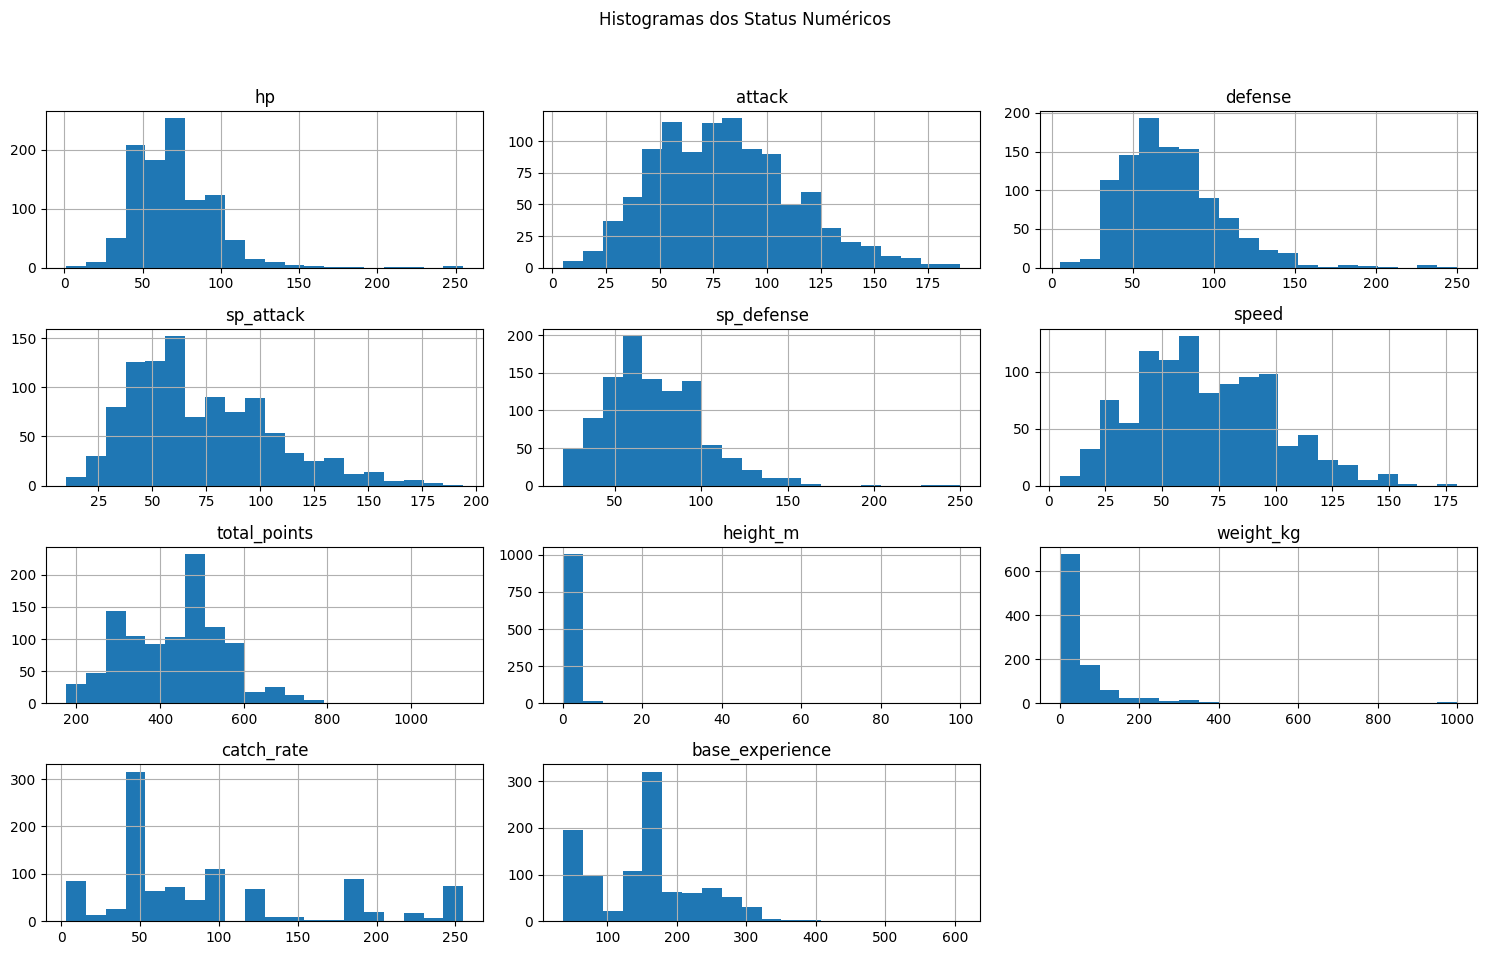

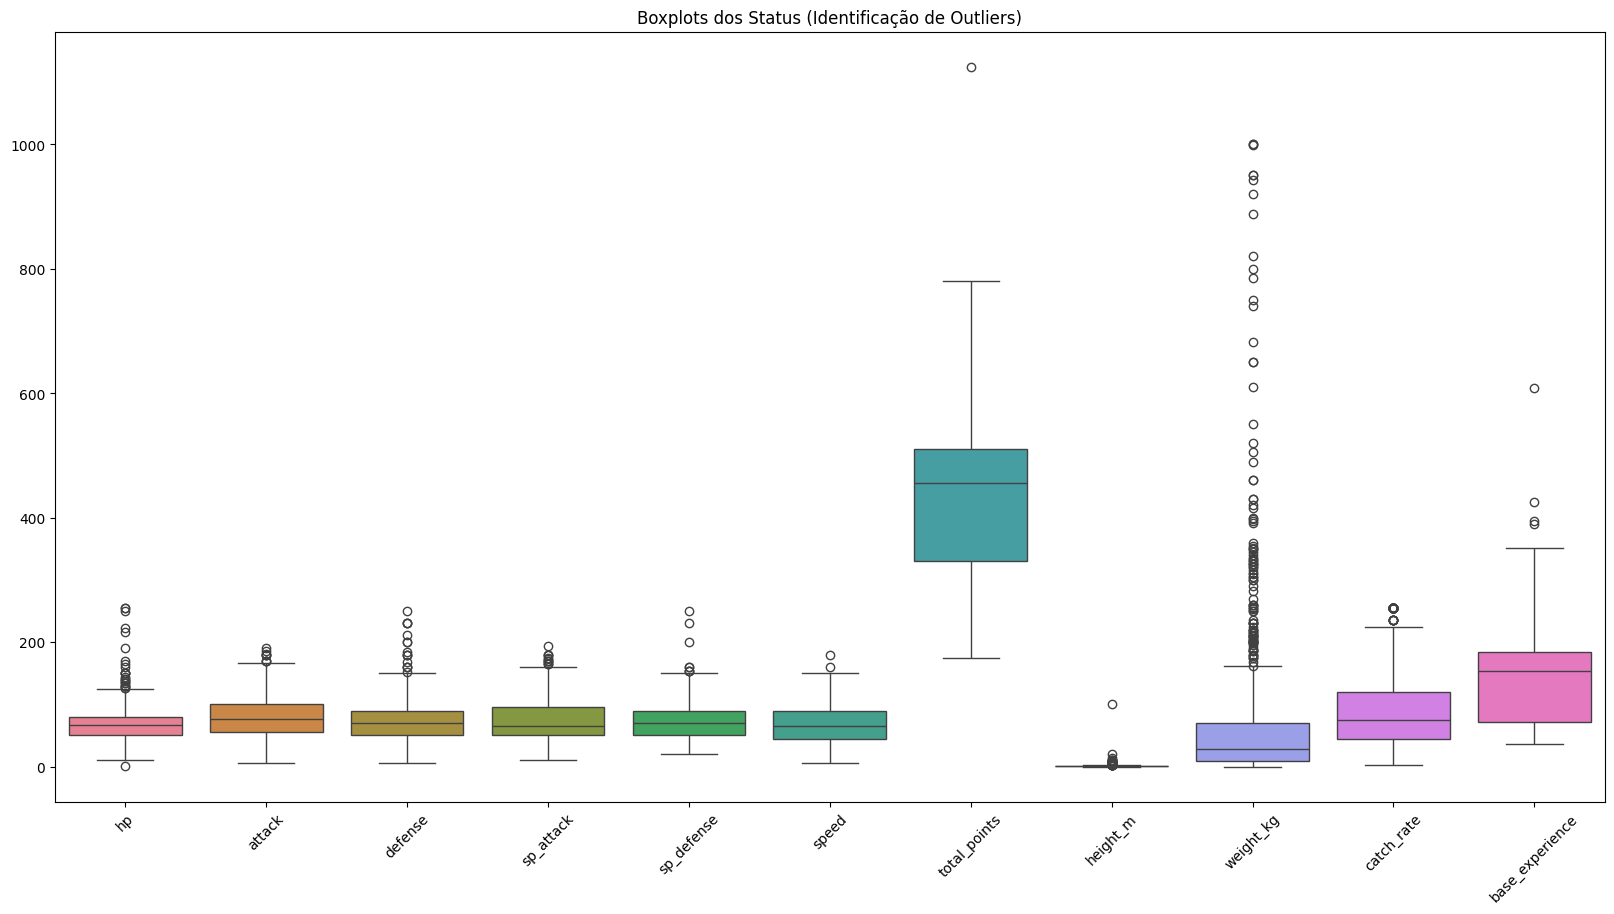

In [ ]:
colunas_status = ['hp', 'attack', 'defense', 'sp_attack', 'sp_defense', 'speed',
                  'total_points', 'height_m', 'weight_kg', 'catch_rate', 'base_experience']

df[colunas_status].hist(bins=20, figsize=(15, 10))
plt.suptitle("Histogramas dos Status Numéricos")
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig('eda_histogramas.png')

print("Histogramas salvos em 'eda_histogramas.png'")
plt.figure(figsize=(20, 10))
sns.boxplot(data=df[colunas_status])
plt.title("Boxplots dos Status (Identificação de Outliers)")
plt.xticks(rotation=45)
plt.savefig('eda_boxplots.png')
print("Boxplots salvos em 'eda_boxplots.png'")

Gráfico do Target salvo em 'eda_countplot_target.png'


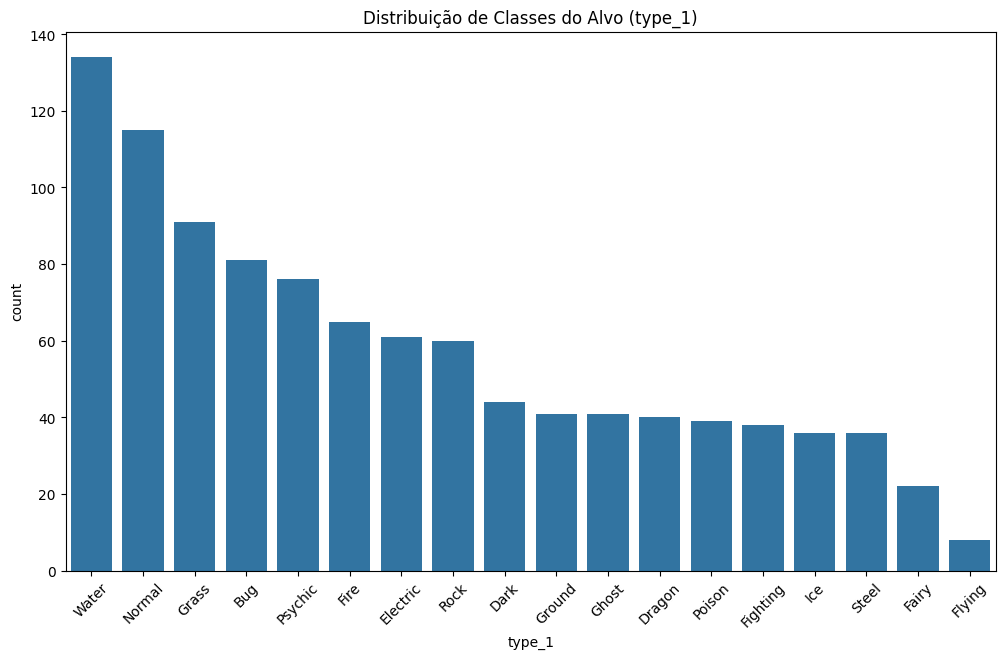

In [ ]:
plt.figure(figsize=(12, 7))
sns.countplot(data=df, x='type_1', order=df['type_1'].value_counts().index)
plt.title('Distribuição de Classes do Alvo (type_1)')
plt.xticks(rotation=45)
plt.savefig('eda_countplot_target.png')
print("Gráfico do Target salvo em 'eda_countplot_target.png'")

Gráfico do Target salvo em 'eda_countplot_target.png'


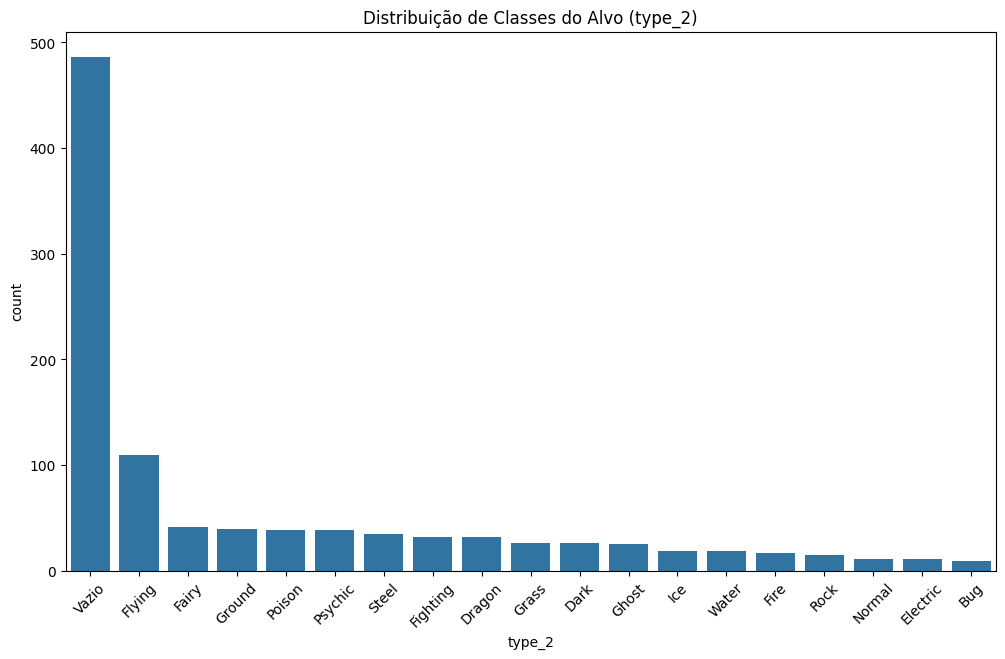

In [ ]:
plt.figure(figsize=(12, 7))
sns.countplot(data=df, x='type_2', order=df['type_2'].value_counts().index)
plt.title('Distribuição de Classes do Alvo (type_2)')
plt.xticks(rotation=45)
plt.savefig('eda_countplot_target.png')
print("Gráfico do Target salvo em 'eda_countplot_target.png'")

Heatmap de correlação foi salvo como 'heatmap_correlacao.png'


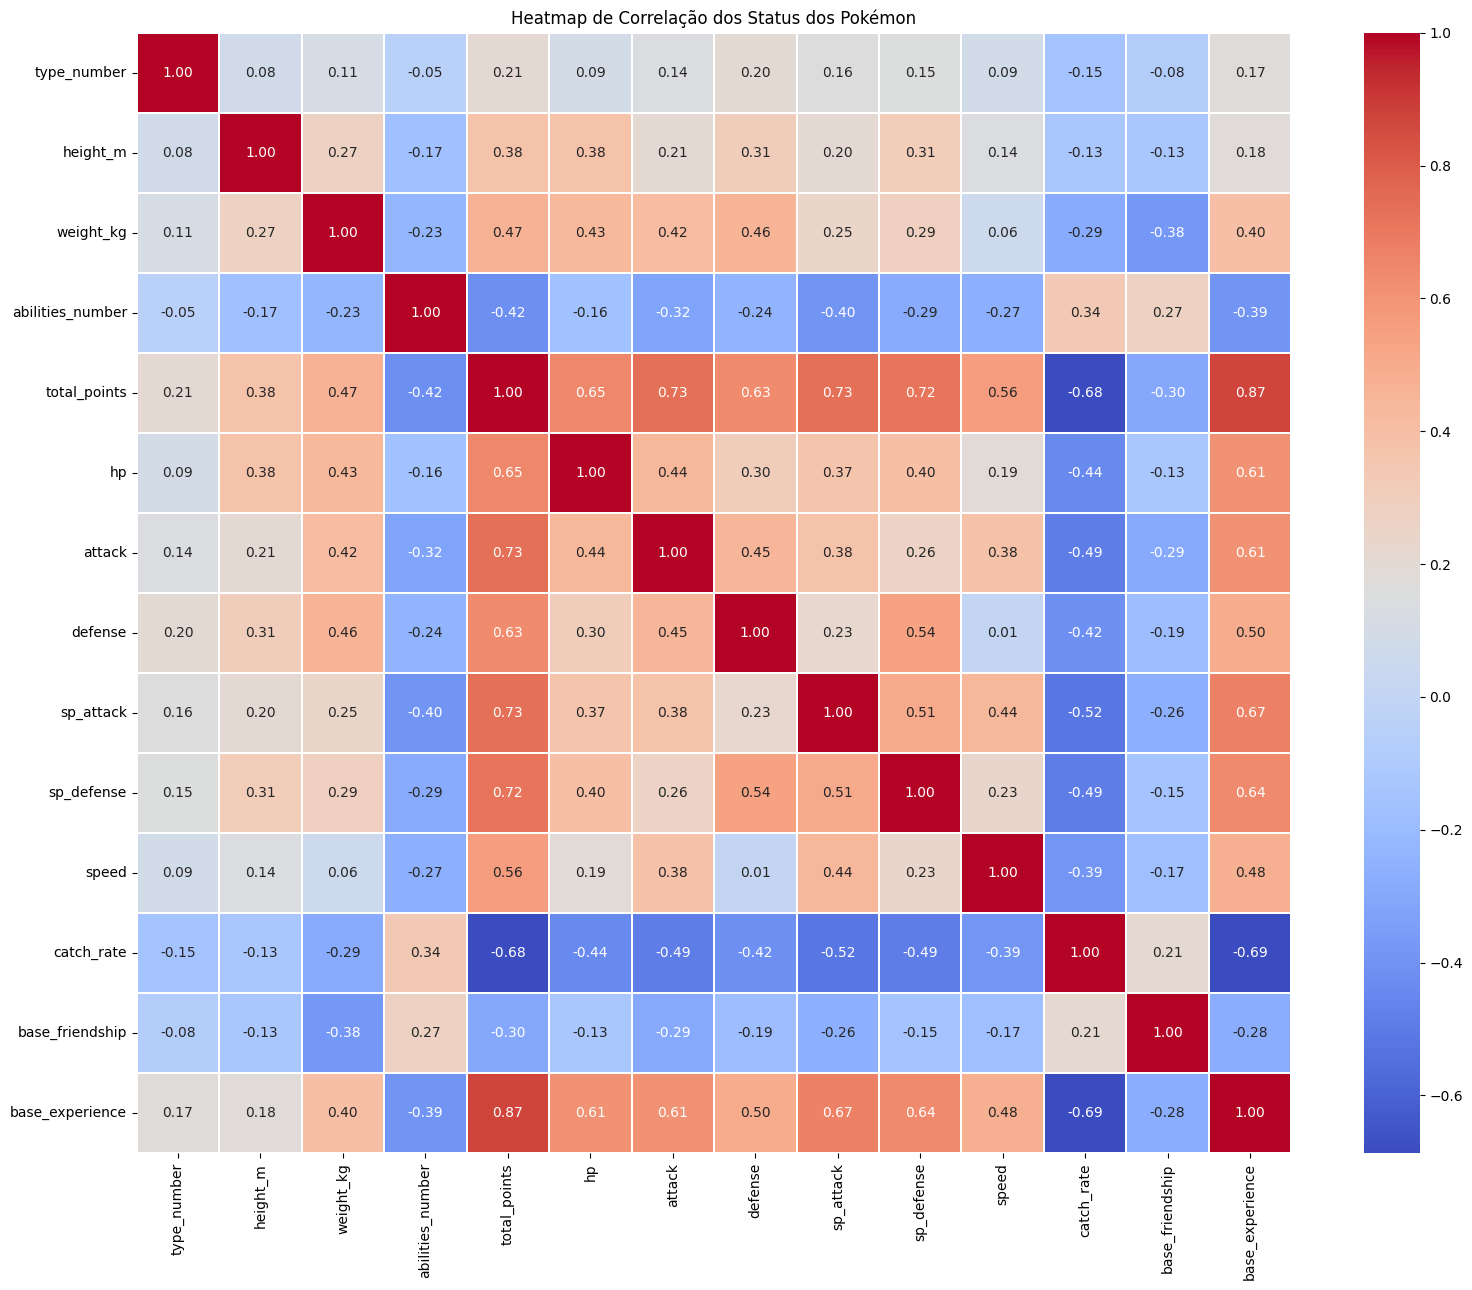

In [ ]:
Features_transformado_numerico = Features.select_dtypes(include='number')

matriz_correlacao = Features_transformado_numerico.corr()

plt.figure(figsize=(16, 13))

sns.heatmap(matriz_correlacao,
            annot=True,
            cmap='coolwarm',
            fmt='.2f',
            linewidths=0.2)

plt.title('Heatmap de Correlação dos Status dos Pokémon')
plt.tight_layout() # Ajusta o layout para evitar cortes

plt.savefig('heatmap_correlacao.png')

print("Heatmap de correlação foi salvo como 'heatmap_correlacao.png'")

Boxplot salvo em 'eda_boxplot_attack_vs_type.png'
type_2    Bug  Dark  Dragon  Electric  Fairy  Fighting  Fire  Flying  Ghost  \
type_1                                                                        
Bug         0     0       0         4      2         4     2      14      1   
Dark        0     0       4         0      3         2     3       5      2   
Dragon      0     0       0         1      1         2     1       6      3   
Electric    0     2       2         0      2         0     1       6      1   
Fairy       0     0       0         0      0         0     0       2      0   
Fighting    0     1       0         0      0         0     0       1      1   
Fire        2     1       2         0      0         7     0       7      2   
Flying      0     0       2         0      0         0     0       0      0   
Ghost       0     1       2         0      1         0     3       3      0   
Grass       0     3       5         0      5         3     0       7      1   
Gr

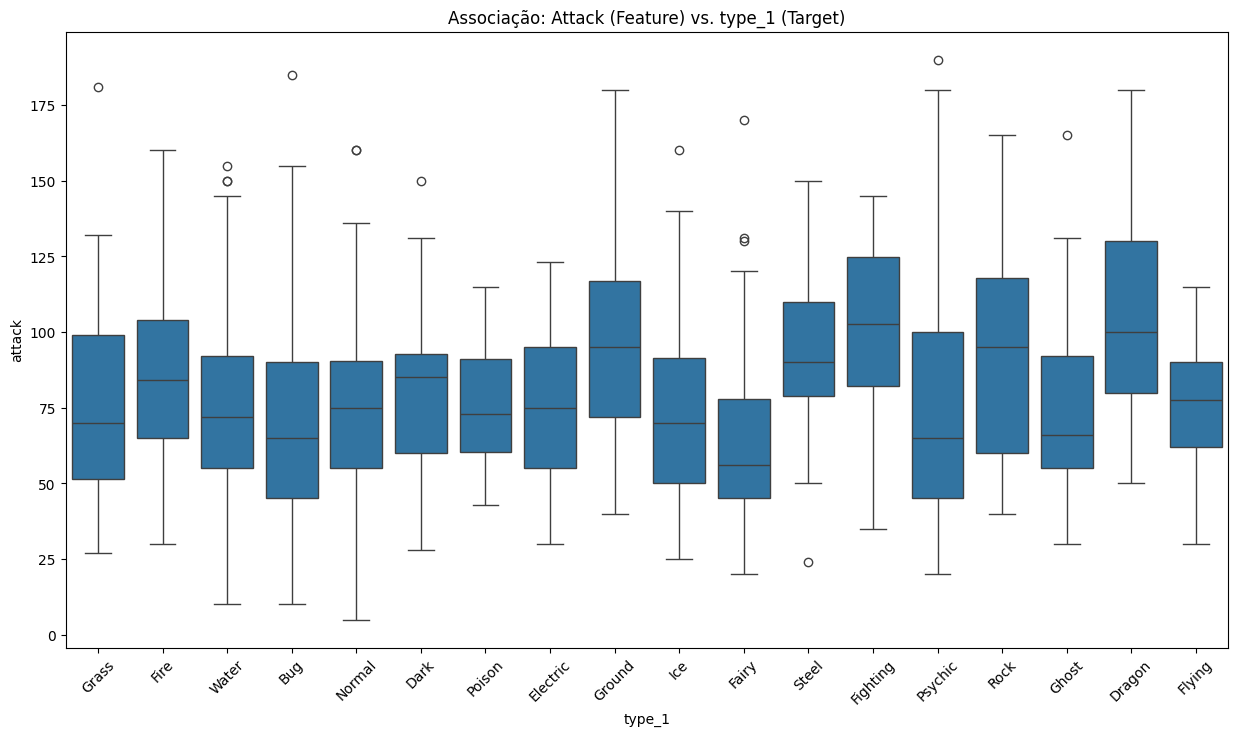

In [ ]:
plt.figure(figsize=(15, 8))

sns.boxplot(data=df, x='type_1', y='attack')
plt.title('Associação: Attack (Feature) vs. type_1 (Target)')
plt.xticks(rotation=45)
plt.savefig('eda_boxplot_attack_vs_type.png')
print("Boxplot salvo em 'eda_boxplot_attack_vs_type.png'")

tabela_cruzada = pd.crosstab(df['type_1'], df['type_2'])
print(tabela_cruzada)

## Considerações
O objetivo aqui para a etapa 2 do trabalho é verificar se é possível predizer o tipo principal de um pokemon baseado em seu status.

Após a verificação dos histogramas é possivel notar que existe um comportamento normal de distribuição entre a quantidade de pokemons e seus status, podendo ser verificado na boxplot que embora existam outilers em todas as categorias a maioria se concentra no peso dos pokemons.
O heatmap entrega que as categorias de poder (ataque, defesa, ataque especial...) todas tem uma realção muito alta entre si, somando isso a associação entre status e target pode ser utilizado para predizer o tipo do pokemon baseado em status.

Sobre o banco é possível perceber que existem mais amostras de alguns pokemons do que de outro. O tipo voadro por exemplo, costuma ser o segundo tipo de varios pokemons, o que faz sua amostragem como primeiro tipo um pouco mais escasso

# APS 2

A divisão treino e teste é de 80/20, onde as colunas nominais foram passadas pelo onehotencoder para serem convertidas em numeros. Além disso as numéricas foram passadas pelo  PowerTransform para balancear suas distribuições.
Algumas rodadas de teste foram realizadas para avaliar os modelos.
Foram testados SVM, Regressão Logistica, Random Forest, KNN, Naive Bayes e XGBOOST, onde a Regressão Logistica atingiu o melhor resultado.
Após isso, foi realizado um SMOTE como segunda estratégia para o balanceamento dos Dados, substituindo o uso do class_weights = balanced. Foram então testados os modelos novamente, porém foi percebido que os resultados não mudaram.

O melhor modelo foi selecionado sendo a Regressão Logistica. Então um GridSearch foi acionado para encontrar os melhores parametros para o uso do modelo, Com o GridSearch Aplicado os resultados obtidos foram:

--- Avaliação Final: Regressão Logística (Otimizada) ---
F1-Score (Weighted) no CONJUNTO DE TESTE: 0.7222
              precision    recall  f1-score   support

         Bug       0.75      0.75      0.75        16
        Dark       0.60      0.67      0.63         9
      Dragon       0.40      0.25      0.31         8
    Electric       0.56      0.75      0.64        12
       Fairy       0.80      0.80      0.80         5
    Fighting       0.71      0.62      0.67         8
        Fire       0.83      0.77      0.80        13
      Flying       0.00      0.00      0.00         2
       Ghost       0.78      0.88      0.82         8
       Grass       0.86      1.00      0.92        18
      Ground       0.64      0.88      0.74         8
         Ice       0.75      0.86      0.80         7
      Normal       0.72      0.78      0.75        23
      Poison       1.00      0.75      0.86         8
     Psychic       0.55      0.40      0.46        15
        Rock       0.62      0.67      0.64        12
       Steel       1.00      0.43      0.60         7
       Water       0.86      0.89      0.87        27

    accuracy                           0.73       206
   macro avg       0.69      0.67      0.67       206
weighted avg       0.73      0.73      0.72       206


Onde as melhores features para o modelo foram:

ohe_categorical__type_2_Vazio                  7.163279
ohe_categorical__ability_2_Vazio               6.144549
power_transform_numerical__abilities_number    4.282107
ohe_categorical__ability_1_Beast Boost         3.819897
power_transform_numerical__type_number         3.505190
ohe_categorical__growth_rate_Fast              3.452582
power_transform_numerical__total_points        3.219097
ohe_categorical__growth_rate_Medium Slow       3.178901
ohe_categorical__growth_rate_Slow              3.153957
ohe_categorical__type_2_Dragon                 3.052072
ohe_categorical__type_2_Psychic                2.824890
ohe_categorical__ability_1_Levitate            2.718236
ohe_categorical__growth_rate_Medium Fast       2.692486
ohe_categorical__ability_hidden_Vazio          2.683401
ohe_categorical__type_2_Poison                 2.564177

O modelo de Regressão Logística alcançou o melhor desempenho entre os testados, atingindo 73% de acurácia e um F1-Score ponderado de 72,2%, o que representa um resultado geral sólido. O sucesso deste modelo se deve, em parte, à sua capacidade de otimizar uma adaptação linear para a separação das categorias, capitalizando em cima de features de alto impacto, como o type_2 ser "Vazio".

Enquanto isso, outros modelos falharam por razões distintas: o KNN sofreu com o alto número de colunas gerado pelo One-Hot Encoding, e modelos mais complexos como Random Forest e XGBoost provavelmente tiveram overfitting. Com muitos atributos e status parecidos, eles podem ter se focado em "ruídos" dos dados de treino, o que dificultou a classificação correta nos dados de teste.

Analisando o F1-Score de 72,2%, vemos que o modelo é ótimo em prever classes comuns e com características distintas, como Grass (F1 0.92), Water (F1 0.87) e Poison (F1 0.86). Ele foi particularmente eficaz ao alcançar 100% de Recall para Grass (encontrando todos) e 100% de Precisão para Poison (nunca errando ao prever esta classe).

No entanto, a média é puxada para baixo por classes mais difíceis. O modelo falhou completamente em Flying (F1 0.00), o que é compreensível, dado que havia apenas 2 amostras de teste. Além disso, teve um desempenho muito ruim em Dragon (F1 0.31) e Psychic (F1 0.46). Desta forma, as piores classificações se deram a partir das categorias com pouca amostragem, como Flying, ou de classes com alta diversidade de segunda tipagem, como o tipo Elétrico, o que confunde o modelo.


##Separação Treino e Teste

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import PowerTransformer, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, f1_score, accuracy_score
from sklearn.metrics import confusion_matrix

In [ ]:
categorical_features = Features.select_dtypes(include=['object', 'category']).columns

numerical_features = Features.select_dtypes(include=['number']).columns

categorical_features = categorical_features.drop('name')
Features = Features.drop('name', axis=1)
print(f"Colunas categóricas a transformar: {list(categorical_features)}")
print(f"Colunas numéricas a manter: {list(numerical_features)}")

X_train, X_test, y_train, y_test = train_test_split(Features, Target_transformed, test_size=0.2, stratify=Target ,random_state=42)

preprocessor = ColumnTransformer(
    transformers=[
        ('ohe_categorical',
         OneHotEncoder(handle_unknown='ignore', drop='first'),
         categorical_features),

        ('power_transform_numerical',
         PowerTransformer(method='yeo-johnson'),
         numerical_features)
    ])

preprocessor.fit(X_train)

X_train_transformed = preprocessor.transform(X_train)
X_test_transformed = preprocessor.transform(X_test)

print("\n--- Dimensões (Linhas, Colunas) ---")
print(f"X_train original: {X_train.shape}")
print(f"X_train transformado: {X_train_transformed.shape}")
print(f"X_test original: {X_test.shape}")
print(f"X_test transformado: {X_test_transformed.shape}")

feature_names = preprocessor.get_feature_names_out()
print("\n--- Algumas das novas colunas ---")
print(feature_names[:10])

Colunas categóricas a transformar: ['type_2', 'ability_1', 'ability_2', 'ability_hidden', 'growth_rate']
Colunas numéricas a manter: ['type_number', 'height_m', 'weight_kg', 'abilities_number', 'total_points', 'hp', 'attack', 'defense', 'sp_attack', 'sp_defense', 'speed', 'catch_rate', 'base_friendship', 'base_experience']

--- Dimensões (Linhas, Colunas) ---
X_train original: (822, 19)
X_train transformado: (822, 494)
X_test original: (206, 19)
X_test transformado: (206, 494)

--- Algumas das novas colunas ---
['ohe_categorical__type_2_Dark' 'ohe_categorical__type_2_Dragon'
 'ohe_categorical__type_2_Electric' 'ohe_categorical__type_2_Fairy'
 'ohe_categorical__type_2_Fighting' 'ohe_categorical__type_2_Fire'
 'ohe_categorical__type_2_Flying' 'ohe_categorical__type_2_Ghost'
 'ohe_categorical__type_2_Grass' 'ohe_categorical__type_2_Ground']


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning:

Found unknown categories in columns [1, 2, 3] during transform. These unknown categories will be encoded as all zeros



Colunas categóricas a transformar: ['type_2', 'ability_1', 'ability_2', 'ability_hidden', 'growth_rate']
Colunas numéricas a manter: ['type_number', 'height_m', 'weight_kg', 'abilities_number', 'total_points', 'hp', 'attack', 'defense', 'sp_attack', 'sp_defense', 'speed', 'catch_rate', 'base_friendship', 'base_experience']

--- Dimensões (Linhas, Colunas) ---
X_train original: (822, 19)
X_train transformado (matriz): (822, 494)
X_test original: (206, 19)
X_test transformado (matriz): (206, 494)

--- Algumas das novas colunas ---
['ohe_categorical__type_2_Dark' 'ohe_categorical__type_2_Dragon'
 'ohe_categorical__type_2_Electric' 'ohe_categorical__type_2_Fairy'
 'ohe_categorical__type_2_Fighting' 'ohe_categorical__type_2_Fire'
 'ohe_categorical__type_2_Flying' 'ohe_categorical__type_2_Ghost'
 'ohe_categorical__type_2_Grass' 'ohe_categorical__type_2_Ground']

--- Visualização dos Dados Transformados (DataFrame) ---
   ohe_categorical__type_2_Dark  ohe_categorical__type_2_Dragon  \
0      

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning:

Found unknown categories in columns [1, 2, 3] during transform. These unknown categories will be encoded as all zeros




Histogramas salvos em 'distributions_after_powertransform.png'


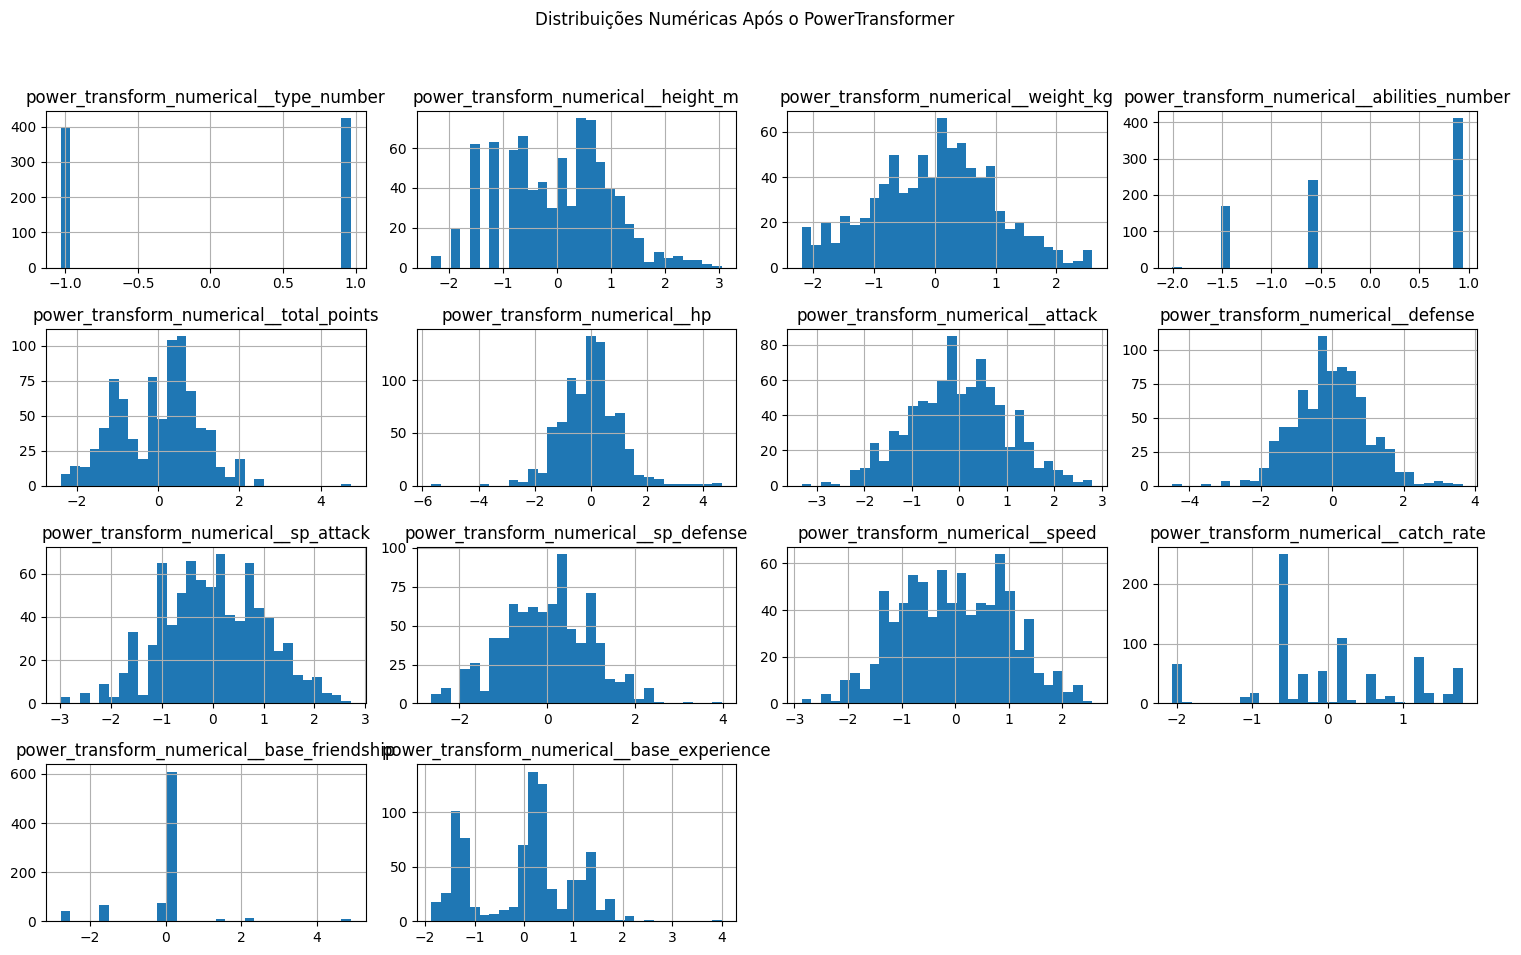

In [ ]:
categorical_features = Features.select_dtypes(include=['object', 'category']).columns
numerical_features = Features.select_dtypes(include=['number']).columns

print(f"Colunas categóricas a transformar: {list(categorical_features)}")
print(f"Colunas numéricas a manter: {list(numerical_features)}")

X_train, X_test, y_train, y_test = train_test_split(
    Features,
    Target_transformed,
    test_size=0.2,
    stratify=Target_transformed,
    random_state=42
)

preprocessor = ColumnTransformer(
    transformers=[
        ('ohe_categorical',
         OneHotEncoder(handle_unknown='ignore', drop='first'),
         categorical_features),

        ('power_transform_numerical',
         PowerTransformer(method='yeo-johnson'),
         numerical_features)
    ])

preprocessor.fit(X_train)

# Estas são as suas Matrizes Esparsas (para o modelo)
X_train_transformed = preprocessor.transform(X_train)
X_test_transformed = preprocessor.transform(X_test)

print("\n--- Dimensões (Linhas, Colunas) ---")
print(f"X_train original: {X_train.shape}")
print(f"X_train transformado (matriz): {X_train_transformed.shape}")
print(f"X_test original: {X_test.shape}")
print(f"X_test transformado (matriz): {X_test_transformed.shape}")

feature_names = preprocessor.get_feature_names_out()
print("\n--- Algumas das novas colunas ---")
print(feature_names[:10])

new_column_names = preprocessor.get_feature_names_out()

df_train_processed = pd.DataFrame(X_train_transformed.toarray(), columns=new_column_names)
df_test_processed = pd.DataFrame(X_test_transformed.toarray(), columns=new_column_names)

print("\n--- Visualização dos Dados Transformados (DataFrame) ---")
print(df_train_processed.head())

print("\nGerando histogramas das features numéricas APÓS o PowerTransform...")

transformed_numerical_cols = df_train_processed.filter(like='power_transform') # <-- CORRIGIDO

transformed_numerical_cols.hist(bins=30, figsize=(15, 10))
plt.suptitle("Distribuições Numéricas Após o PowerTransformer")
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig('distributions_after_powertransform.png')

print("\nHistogramas salvos em 'distributions_after_powertransform.png'")

In [ ]:
try:

    # 'le' é o LabelEncoder

    class_names = le.classes_

    print(f"Nomes das classes (target) encontrados via LabelEncoder.")

except NameError:

    print("AVISO: Objeto 'le' (LabelEncoder) não encontrado.")

    class_names = np.unique(y_train)



try:

    # 'preprocessor' é o ColumnTransformer

    feature_names = preprocessor.get_feature_names_out()

    print(f"Nomes das features encontrados via ColumnTransformer.")

except NameError:

    print("AVISO: Objeto 'preprocessor' (ColumnTransformer) não encontrado.")

    feature_names = None

Nomes das classes (target) encontrados via LabelEncoder.
Nomes das features encontrados via ColumnTransformer.


##Regressão


--- Treinando e Avaliando: Regressão Logística ---
F1-Score (Weighted): 0.6840
              precision    recall  f1-score   support

         Bug       0.81      0.81      0.81        16
        Dark       0.50      0.67      0.57         9
      Dragon       0.40      0.50      0.44         8
    Electric       0.46      0.50      0.48        12
       Fairy       0.67      0.80      0.73         5
    Fighting       0.56      0.62      0.59         8
        Fire       0.90      0.69      0.78        13
      Flying       0.00      0.00      0.00         2
       Ghost       0.86      0.75      0.80         8
       Grass       0.89      0.94      0.92        18
      Ground       0.64      0.88      0.74         8
         Ice       0.75      0.86      0.80         7
      Normal       0.69      0.78      0.73        23
      Poison       0.88      0.88      0.88         8
     Psychic       0.50      0.40      0.44        15
        Rock       0.73      0.67      0.70        12
 

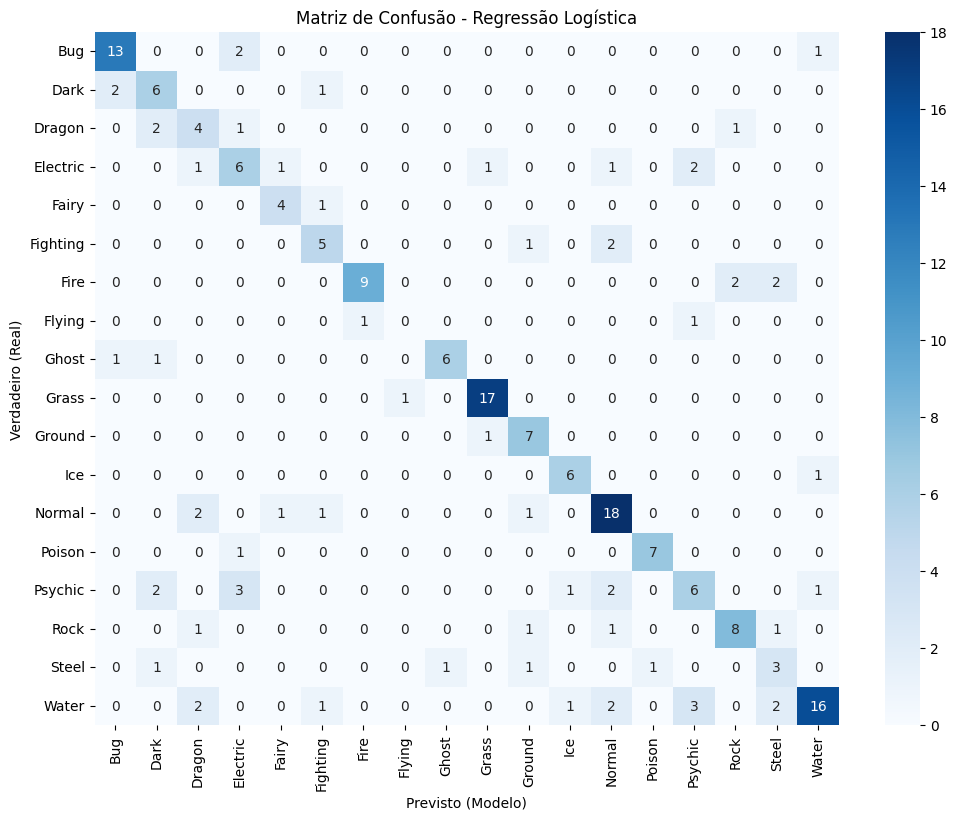


--- Principais Features para: Regressão Logística ---
ohe_categorical__type_2_Vazio                  0.933805
ohe_categorical__ability_2_Vazio               0.827908
ohe_categorical__growth_rate_Medium Slow       0.682488
ohe_categorical__growth_rate_Slow              0.661656
ohe_categorical__growth_rate_Fast              0.605870
power_transform_numerical__abilities_number    0.555359
ohe_categorical__type_2_Psychic                0.553616
ohe_categorical__ability_1_Swift Swim          0.539458
ohe_categorical__ability_1_Levitate            0.509040
ohe_categorical__type_2_Water                  0.507945
ohe_categorical__ability_1_Swarm               0.503914
ohe_categorical__type_2_Poison                 0.485859
ohe_categorical__ability_1_Keen Eye            0.485338
ohe_categorical__ability_1_Blaze               0.473059
ohe_categorical__ability_hidden_Telepathy      0.469709
dtype: float64

--- Lista de Erros para: Regressão Logística ---
Total de erros: 65 de 206 amostras de te

In [ ]:
name = "Regressão Logística"
model = LogisticRegression(
    max_iter=10000,
    random_state=42,
    class_weight='balanced',
    solver = 'liblinear'
)

print(f"\n=======================================================")
print(f"--- Treinando e Avaliando: {name} ---")

# --- 2. Treinar ---
model.fit(X_train_transformed, y_train)

# --- 3. Prever e Avaliar ---
y_pred = model.predict(X_test_transformed)

f1 = f1_score(y_test, y_pred, average='weighted')
print(f"F1-Score (Weighted): {f1:.4f}")
print(classification_report(y_test, y_pred, target_names=class_names, zero_division=0))

# --- 4. Matriz de Confusão ---
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(12, 9))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title(f'Matriz de Confusão - {name}')
plt.ylabel('Verdadeiro (Real)')
plt.xlabel('Previsto (Modelo)')
plt.xticks(rotation=90); plt.yticks(rotation=0)
plt.show()

# --- 5. Principais Features ---
print(f"\n--- Principais Features para: {name} ---")
if feature_names is not None:
    if hasattr(model, 'coef_'): # Para Regressão Logística
        # Para multiclasse, tiramos a média do valor absoluto dos coeficientes
        importances = np.mean(np.abs(model.coef_), axis=0)
        df_imp = pd.Series(importances, index=feature_names)
        print(df_imp.sort_values(ascending=False).head(15))
    else:
        print("Modelo não possui atributo .coef_")
else:
    print("Não foi possível extrair nomes das features do 'preprocessor'.")

# --- 6. Lista de Erros (Forma Corrigida) ---
print(f"\n--- Lista de Erros para: {name} ---")

# Converte os números de volta para texto (ex: 0 -> 'Water')
y_test_text = le.inverse_transform(y_test)
y_pred_text = le.inverse_transform(y_pred)

try:
    nomes_dos_pokemons_no_teste = df.loc[X_test.index, 'name']
except NameError:
    print("Erro: DataFrame 'df' original não encontrado para buscar os nomes.")
    nomes_dos_pokemons_no_teste = X_test.index # Usa o índice como fallback

# Cria o DataFrame de resultados
df_resultados = pd.DataFrame({
    'name': nomes_dos_pokemons_no_teste, # <-- MUDANÇA AQUI
    'type_1 (Real)': y_test_text,
    'type_1 (Previsto)': y_pred_text
})

# Filtra apenas pelas linhas onde o modelo errou
errors_df = df_resultados[df_resultados['type_1 (Real)'] != df_resultados['type_1 (Previsto)']].copy()

if len(errors_df) == 0:
    print("Nenhum erro encontrado neste modelo!")
else:
    print(f"Total de erros: {len(errors_df)} de {len(df_resultados)} amostras de teste.")
    print(errors_df.head(20))

##Random Forest


--- Treinando e Avaliando: Random Forest ---
F1-Score (Weighted): 0.5778
              precision    recall  f1-score   support

         Bug       0.59      0.62      0.61        16
        Dark       0.46      0.67      0.55         9
      Dragon       0.62      0.62      0.62         8
    Electric       0.45      0.42      0.43        12
       Fairy       1.00      0.60      0.75         5
    Fighting       1.00      0.38      0.55         8
        Fire       0.71      0.38      0.50        13
      Flying       0.00      0.00      0.00         2
       Ghost       0.83      0.62      0.71         8
       Grass       0.62      0.72      0.67        18
      Ground       1.00      0.50      0.67         8
         Ice       1.00      0.86      0.92         7
      Normal       0.47      0.70      0.56        23
      Poison       0.75      0.38      0.50         8
     Psychic       0.47      0.53      0.50        15
        Rock       0.50      0.50      0.50        12
       

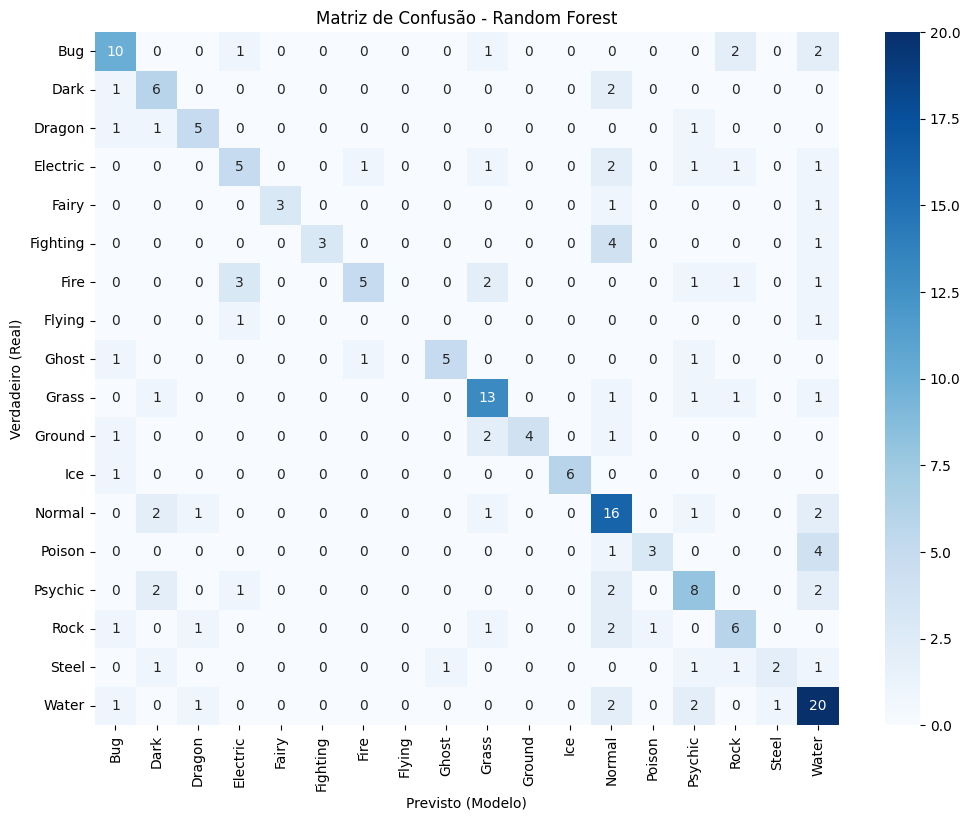


--- Principais Features para: Random Forest ---
Modelo não possui atributo .feature_importance_

--- Lista de Erros para: Random Forest ---
Total de erros: 86 de 206 amostras de teste.
                       name type_1 (Real) type_1 (Previsto)
30                    Ekans        Poison            Normal
840               Volcanion          Fire           Psychic
372                Illumise           Bug             Water
965                  Yamper      Electric             Water
140                 Koffing        Poison             Water
256                 Shuckle           Bug              Rock
903              Turtonator          Fire              Rock
781                 Pancham      Fighting            Normal
553                 Leafeon         Grass              Dark
102       Galarian Rapidash       Psychic            Normal
555                 Gliscor        Ground               Bug
784                  Espurr       Psychic             Water
543          Mega Abomasnow       

In [ ]:
name = "Random Forest"
model = RandomForestClassifier(
    class_weight='balanced',
    random_state=42,
    n_estimators=150,
    max_depth=100,
)

print(f"\n=======================================================")
print(f"--- Treinando e Avaliando: {name} ---")

# --- 2. Treinar ---
model.fit(X_train_transformed, y_train)

# --- 3. Prever e Avaliar ---
y_pred = model.predict(X_test_transformed)

f1 = f1_score(y_test, y_pred, average='weighted')
print(f"F1-Score (Weighted): {f1:.4f}")
print(classification_report(y_test, y_pred, target_names=class_names, zero_division=0))

# --- 4. Matriz de Confusão ---
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(12, 9))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title(f'Matriz de Confusão - {name}')
plt.ylabel('Verdadeiro (Real)')
plt.xlabel('Previsto (Modelo)')
plt.xticks(rotation=90); plt.yticks(rotation=0)
plt.show()

# --- 5. Principais Features ---
print(f"\n--- Principais Features para: {name} ---")
if feature_names is not None:
    if hasattr(model, 'feature_importance_'):
        importances = model.feature_importance_
        df_imp = pd.Series(importances, index=feature_names)
        print(df_imp.sort_values(ascending=False).head(15))
    else:
        print("Modelo não possui atributo .feature_importance_")
else:
    print("Não foi possível extrair nomes das features do 'preprocessor'.")

# --- 6. Lista de Erros (Forma Corrigida) ---
print(f"\n--- Lista de Erros para: {name} ---")

# Converte os números de volta para texto (ex: 0 -> 'Water')
y_test_text = le.inverse_transform(y_test)
y_pred_text = le.inverse_transform(y_pred)

try:
    nomes_dos_pokemons_no_teste = df.loc[X_test.index, 'name']
except NameError:
    print("Erro: DataFrame 'df' original não encontrado para buscar os nomes.")
    nomes_dos_pokemons_no_teste = X_test.index # Usa o índice como fallback

# Cria o DataFrame de resultados
df_resultados = pd.DataFrame({
    'name': nomes_dos_pokemons_no_teste, # <-- MUDANÇA AQUI
    'type_1 (Real)': y_test_text,
    'type_1 (Previsto)': y_pred_text
})

# Filtra apenas pelas linhas onde o modelo errou
errors_df = df_resultados[df_resultados['type_1 (Real)'] != df_resultados['type_1 (Previsto)']].copy()

if len(errors_df) == 0:
    print("Nenhum erro encontrado neste modelo!")
else:
    print(f"Total de erros: {len(errors_df)} de {len(df_resultados)} amostras de teste.")
    print(errors_df.head(20))

##KNN


--- Treinando e Avaliando: K-Nearest Neighbors (KNN) ---
F1-Score (Weighted): 0.3821
              precision    recall  f1-score   support

         Bug       0.31      0.62      0.42        16
        Dark       0.14      0.33      0.20         9
      Dragon       0.21      0.38      0.27         8
    Electric       0.33      0.58      0.42        12
       Fairy       0.44      0.80      0.57         5
    Fighting       0.29      0.50      0.36         8
        Fire       0.54      0.54      0.54        13
      Flying       0.00      0.00      0.00         2
       Ghost       0.56      0.62      0.59         8
       Grass       0.64      0.50      0.56        18
      Ground       0.25      0.25      0.25         8
         Ice       0.25      0.14      0.18         7
      Normal       0.58      0.48      0.52        23
      Poison       0.25      0.12      0.17         8
     Psychic       0.33      0.07      0.11        15
        Rock       0.75      0.25      0.38      

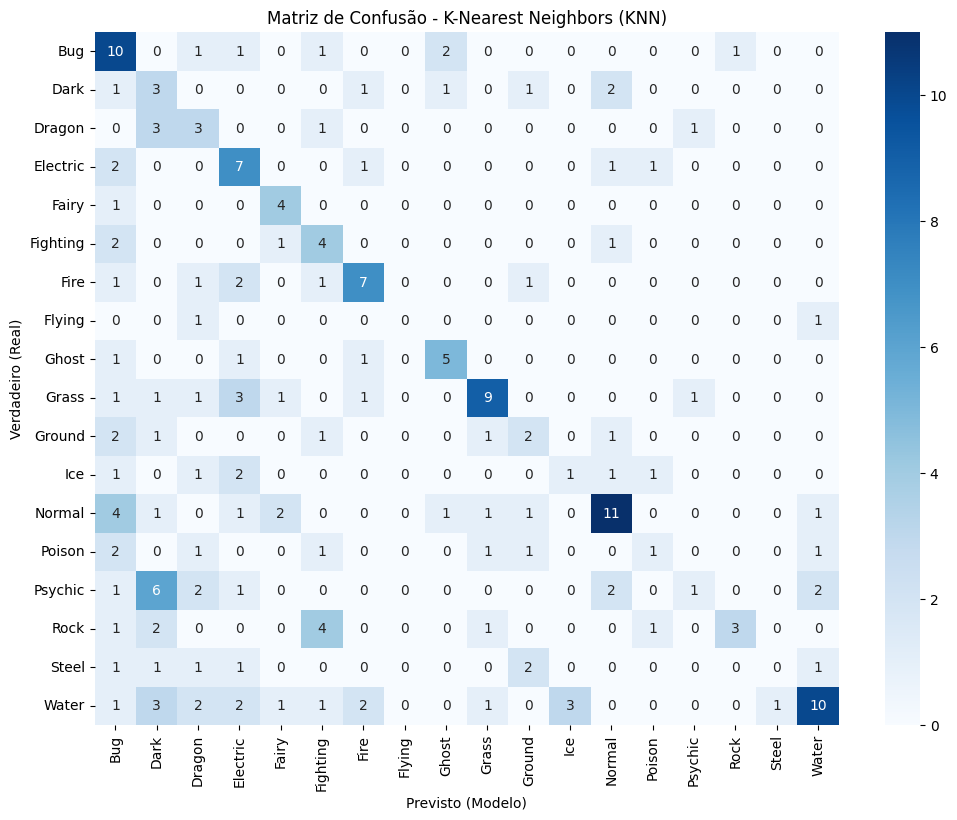


--- Principais Features para: K-Nearest Neighbors (KNN) ---
O modelo K-Nearest Neighbors (KNN) não fornece feature importance direta (.coef_ ou .feature_importance_).

--- Lista de Erros para: K-Nearest Neighbors (KNN) ---
Total de erros: 125 de 206 amostras de teste.
                  name type_1 (Real) type_1 (Previsto)
30               Ekans        Poison               Bug
956           Orbeetle           Bug             Ghost
347            Loudred        Normal               Bug
840          Volcanion          Fire            Dragon
965             Yamper      Electric            Normal
950           Greedent        Normal             Fairy
148    Mega Kangaskhan        Normal             Fairy
140            Koffing        Poison               Bug
256            Shuckle           Bug              Rock
903         Turtonator          Fire            Ground
781            Pancham      Fighting               Bug
553            Leafeon         Grass            Dragon
102  Galarian R

In [ ]:
name = "K-Nearest Neighbors (KNN)"
model = KNeighborsClassifier(n_neighbors=3)

print(f"\n=======================================================")
print(f"--- Treinando e Avaliando: {name} ---")

# --- 2. Treinar ---
model.fit(X_train_transformed, y_train)

# --- 3. Prever e Avaliar ---
y_pred = model.predict(X_test_transformed)

f1 = f1_score(y_test, y_pred, average='weighted')
print(f"F1-Score (Weighted): {f1:.4f}")
print(classification_report(y_test, y_pred, target_names=class_names, zero_division=0))

# --- 4. Matriz de Confusão ---
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(12, 9))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title(f'Matriz de Confusão - {name}')
plt.ylabel('Verdadeiro (Real)')
plt.xlabel('Previsto (Modelo)')
plt.xticks(rotation=90); plt.yticks(rotation=0)
plt.show()

# --- 5. Principais Features ---
print(f"\n--- Principais Features para: {name} ---")
print(f"O modelo {name} não fornece feature importance direta (.coef_ ou .feature_importance_).")

# --- 6. Lista de Erros (Forma Corrigida) ---
print(f"\n--- Lista de Erros para: {name} ---")

# Converte os números de volta para texto (ex: 0 -> 'Water')
y_test_text = le.inverse_transform(y_test)
y_pred_text = le.inverse_transform(y_pred)

try:
    nomes_dos_pokemons_no_teste = df.loc[X_test.index, 'name']
except NameError:
    print("Erro: DataFrame 'df' original não encontrado para buscar os nomes.")
    nomes_dos_pokemons_no_teste = X_test.index # Usa o índice como fallback

# Cria o DataFrame de resultados
df_resultados = pd.DataFrame({
    'name': nomes_dos_pokemons_no_teste, # <-- MUDANÇA AQUI
    'type_1 (Real)': y_test_text,
    'type_1 (Previsto)': y_pred_text
})

# Filtra apenas pelas linhas onde o modelo errou
errors_df = df_resultados[df_resultados['type_1 (Real)'] != df_resultados['type_1 (Previsto)']].copy()

if len(errors_df) == 0:
    print("Nenhum erro encontrado neste modelo!")
else:
    print(f"Total de erros: {len(errors_df)} de {len(df_resultados)} amostras de teste.")
    print(errors_df.head(20))


--- Treinando e Avaliando: XGBoost ---


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning:

[02:39:28] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.




F1-Score (Weighted): 0.5006
              precision    recall  f1-score   support

         Bug       0.83      0.62      0.71        16
        Dark       0.38      0.56      0.45         9
      Dragon       0.45      0.62      0.53         8
    Electric       0.36      0.42      0.38        12
       Fairy       0.00      0.00      0.00         5
    Fighting       0.57      0.50      0.53         8
        Fire       0.53      0.62      0.57        13
      Flying       0.00      0.00      0.00         2
       Ghost       0.67      0.50      0.57         8
       Grass       0.74      0.78      0.76        18
      Ground       0.33      0.38      0.35         8
         Ice       0.75      0.43      0.55         7
      Normal       0.50      0.74      0.60        23
      Poison       0.67      0.25      0.36         8
     Psychic       0.38      0.20      0.26        15
        Rock       0.33      0.33      0.33        12
       Steel       0.00      0.00      0.00         7

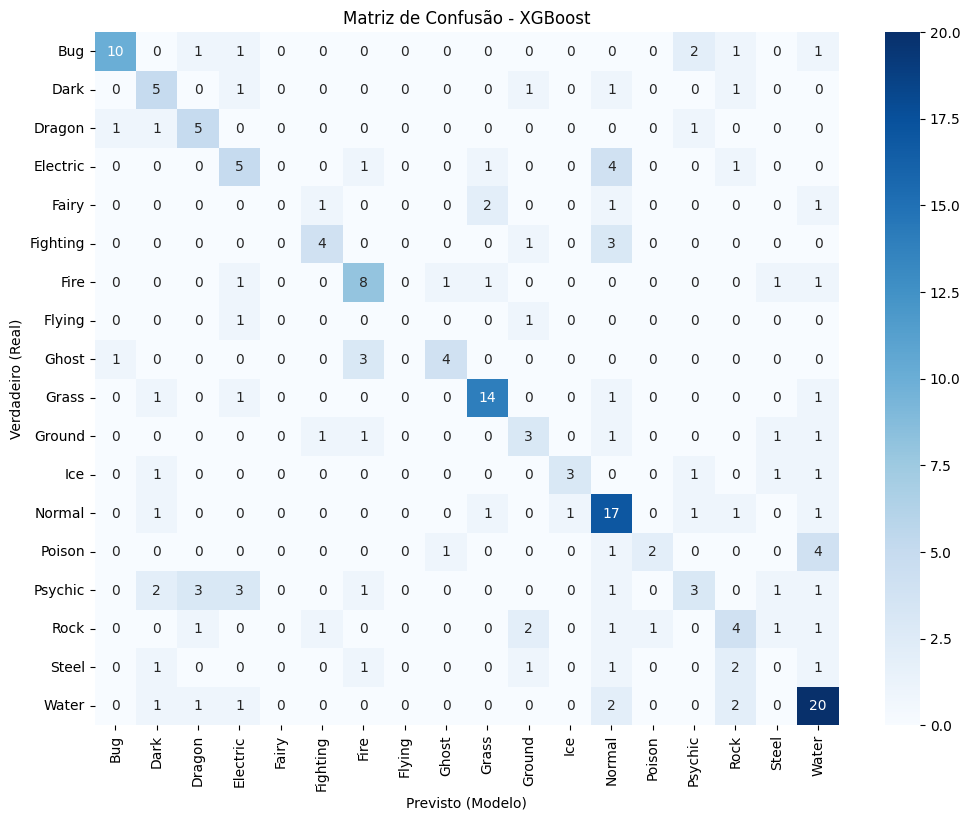


--- Principais Features para: XGBoost ---
ohe_categorical__ability_1_Blaze              0.035496
ohe_categorical__ability_1_Overgrow           0.030814
ohe_categorical__ability_1_Torrent            0.023554
ohe_categorical__ability_1_Swarm              0.023110
ohe_categorical__ability_1_Synchronize        0.021738
ohe_categorical__ability_1_Chlorophyll        0.020494
ohe_categorical__ability_2_Frisk              0.020145
ohe_categorical__ability_1_Guts               0.019836
ohe_categorical__ability_1_Swift Swim         0.015992
ohe_categorical__ability_1_Oblivious          0.015683
ohe_categorical__ability_1_Static             0.015105
ohe_categorical__ability_hidden_Overcoat      0.014916
ohe_categorical__ability_1_Water Absorb       0.013756
ohe_categorical__ability_hidden_Aroma Veil    0.013382
ohe_categorical__ability_2_Rivalry            0.013302
dtype: float32

--- Lista de Erros para: XGBoost ---
Total de erros: 99 de 206 amostras de teste.
                      name type_1 

In [ ]:
from xgboost import XGBClassifier

name = "XGBoost"
model = XGBClassifier(
    random_state=42,
    use_label_encoder=False,
    eval_metric='mlogloss'
)

print(f"\n=======================================================")
print(f"--- Treinando e Avaliando: {name} ---")

# --- 2. Treinar ---
# (Se estiver usando SMOTE, use .fit(X_train_smote, y_train_smote))
model.fit(X_train_transformed, y_train)

# --- 3. Prever e Avaliar ---
y_pred = model.predict(X_test_transformed)

f1 = f1_score(y_test, y_pred, average='weighted')
print(f"F1-Score (Weighted): {f1:.4f}")
print(classification_report(y_test, y_pred, target_names=class_names, zero_division=0))

# --- 4. Matriz de Confusão ---
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(12, 9))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title(f'Matriz de Confusão - {name}')
plt.ylabel('Verdadeiro (Real)')
plt.xlabel('Previsto (Modelo)')
plt.xticks(rotation=90); plt.yticks(rotation=0)
plt.show()

# --- 5. Principais Features ---
print(f"\n--- Principais Features para: {name} ---")
if feature_names is not None:
    # --- CORREÇÃO 1: Adicionado "s" em .feature_importances_ ---
    if hasattr(model, 'feature_importances_'):
        importances = model.feature_importances_
        df_imp = pd.Series(importances, index=feature_names)
        print(df_imp.sort_values(ascending=False).head(15))
    else:
        print("Modelo não possui atributo .feature_importances_")
else:
    print("Não foi possível extrair nomes das features do 'preprocessor'.")

# --- 6. Lista de Erros (Forma Corrigida) ---
print(f"\n--- Lista de Erros para: {name} ---")

# Converte os números de volta para texto (ex: 0 -> 'Water')
y_test_text = le.inverse_transform(y_test)
y_pred_text = le.inverse_transform(y_pred)

try:
    # --- CORREÇÃO 2: Usando X_test.index (do DataFrame) ---
    # (em vez de X_test_transformed.index, que não existe)
    nomes_dos_pokemons_no_teste = df.loc[X_test.index, 'name']
except NameError:
    print("Erro: DataFrame 'df' original não encontrado para buscar os nomes.")
    nomes_dos_pokemons_no_teste = X_test.index
except KeyError:
    print("Erro: A coluna 'name' não foi encontrada no 'df' original.")
    nomes_dos_pokemons_no_teste = X_test.index

# Cria o DataFrame de resultados
df_resultados = pd.DataFrame({
    'name': nomes_dos_pokemons_no_teste,
    'type_1 (Real)': y_test_text,
    'type_1 (Previsto)': y_pred_text
})

# Filtra apenas pelas linhas onde o modelo errou
errors_df = df_resultados[df_resultados['type_1 (Real)'] != df_resultados['type_1 (Previsto)']].copy()

if len(errors_df) == 0:
    print("Nenhum erro encontrado neste modelo!")
else:
    print(f"Total de erros: {len(errors_df)} de {len(df_resultados)} amostras de teste.")
    print(errors_df.head(20))

## Naive Bayes


--- Treinando e Avaliando: Gaussian Naive Bayes ---
Convertendo dados para formato denso (necessário para Naive Bayes)...
F1-Score (Weighted): 0.6609
              precision    recall  f1-score   support

         Bug       0.91      0.62      0.74        16
        Dark       0.71      0.56      0.62         9
      Dragon       0.17      0.25      0.20         8
    Electric       1.00      0.58      0.74        12
       Fairy       0.50      1.00      0.67         5
    Fighting       0.33      0.50      0.40         8
        Fire       0.90      0.69      0.78        13
      Flying       0.17      0.50      0.25         2
       Ghost       0.35      0.88      0.50         8
       Grass       1.00      0.94      0.97        18
      Ground       1.00      0.75      0.86         8
         Ice       0.86      0.86      0.86         7
      Normal       0.70      0.61      0.65        23
      Poison       0.80      1.00      0.89         8
     Psychic       0.20      0.13     

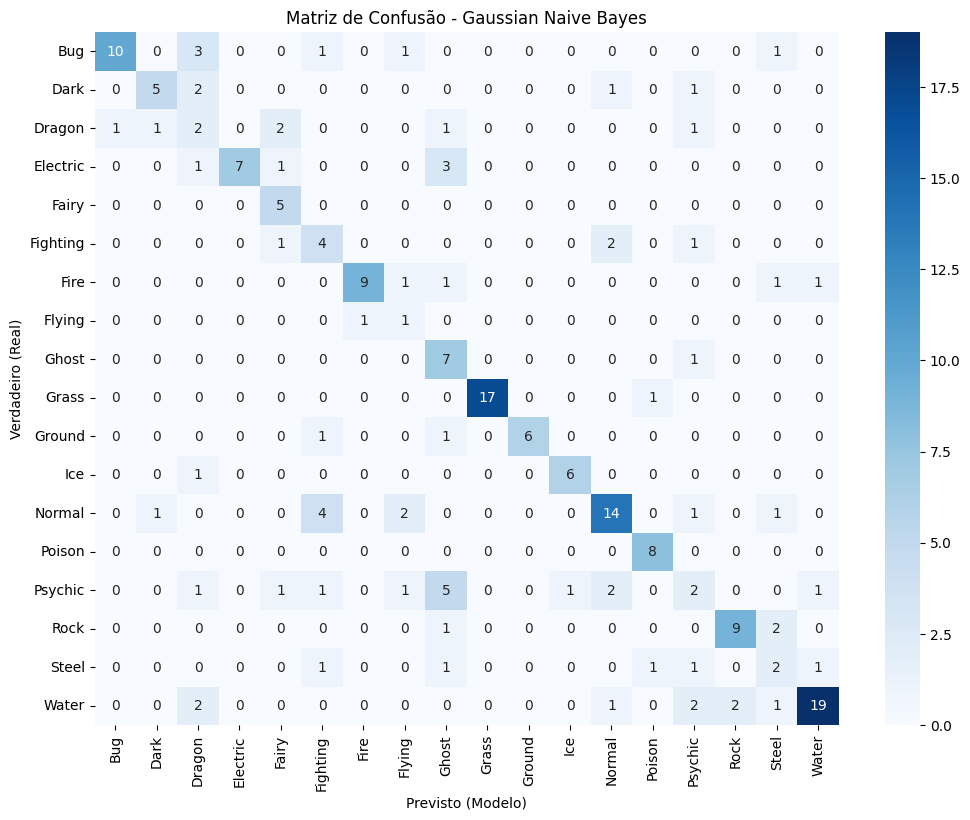


--- Principais Features para: Gaussian Naive Bayes ---
O modelo Gaussian Naive Bayes não fornece uma lista de 'feature importance' simples.
A importância é inferida pela média (theta_) de cada feature por classe.

--- Lista de Erros para: Gaussian Naive Bayes ---
Total de erros: 73 de 206 amostras de teste.
                    name type_1 (Real) type_1 (Previsto)
956             Orbeetle           Bug          Fighting
840            Volcanion          Fire            Flying
965               Yamper      Electric             Fairy
148      Mega Kangaskhan        Normal            Flying
893               Wimpod           Bug            Flying
256              Shuckle           Bug             Steel
903           Turtonator          Fire             Water
102    Galarian Rapidash       Psychic            Normal
14               Metapod           Bug            Dragon
784               Espurr       Psychic            Flying
977          Barraskewda         Water              Rock
891   

In [ ]:
from sklearn.naive_bayes import GaussianNB

name = "Gaussian Naive Bayes"
model = GaussianNB()

print(f"\n=======================================================")
print(f"--- Treinando e Avaliando: {name} ---")

# --- 2. Treinar ---
print("Convertendo dados para formato denso (necessário para Naive Bayes)...")
# Converte o X de treino para denso

model.fit(X_train_transformed.toarray(), y_train)

# --- 3. Prever e Avaliar ---
y_pred = model.predict(X_test_transformed.toarray())
f1 = f1_score(y_test, y_pred, average='weighted')
print(f"F1-Score (Weighted): {f1:.4f}")
print(classification_report(y_test, y_pred, target_names=class_names, zero_division=0))

# --- 4. Matriz de Confusão ---
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(12, 9))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title(f'Matriz de Confusão - {name}')
plt.ylabel('Verdadeiro (Real)')
plt.xlabel('Previsto (Modelo)')
plt.xticks(rotation=90); plt.yticks(rotation=0)
plt.show()

# --- 5. Principais Features ---
print(f"\n--- Principais Features para: {name} ---")
print(f"O modelo {name} não fornece uma lista de 'feature importance' simples.")
print("A importância é inferida pela média (theta_) de cada feature por classe.")

# --- 6. Lista de Erros (Forma Corrigida) ---
print(f"\n--- Lista de Erros para: {name} ---")

# Converte os números de volta para texto (ex: 0 -> 'Water')
y_test_text = le.inverse_transform(y_test)
y_pred_text = le.inverse_transform(y_pred)

try:
    nomes_dos_pokemons_no_teste = df.loc[X_test.index, 'name']
except NameError:
    print("Erro: DataFrame 'df' original não encontrado para buscar os nomes.")
    nomes_dos_pokemons_no_teste = X_test.index

# Cria o DataFrame de resultados
df_resultados = pd.DataFrame({
    'name': nomes_dos_pokemons_no_teste,
    'type_1 (Real)': y_test_text,
    'type_1 (Previsto)': y_pred_text
})

# Filtra apenas pelas linhas onde o modelo errou
errors_df = df_resultados[df_resultados['type_1 (Real)'] != df_resultados['type_1 (Previsto)']].copy()

if len(errors_df) == 0:
    print("Nenhum erro encontrado neste modelo!")
else:
    print(f"Total de erros: {len(errors_df)} de {len(df_resultados)} amostras de teste.")
    print(errors_df.head(20))

## Aplicando SMOTE para classes desbalanceadas


In [ ]:
!pip install imbalanced-learn

In [ ]:
from collections import Counter
from sklearn.datasets import make_classification
from imblearn.over_sampling import SMOTE

In [ ]:
try:
    smote = SMOTE(k_neighbors=3, random_state=42)
except ValueError:
    print("k_neighbors=3 falhou (provavelmente uma classe tem < 4 exemplos). Tentando k=1.")
    smote = SMOTE(k_neighbors=1, random_state=42)

print(f"Formato original de X_train: {X_train_transformed.shape}")
print(f"Formato original de y_train: {y_train.shape}")
print(f"Contagem de classes (y_train) ANTES do SMOTE:\n{pd.Series(y_train).value_counts().sort_index()}")

X_train_smote, y_train_smote = smote.fit_resample(X_train_transformed, y_train)

print(f"\nFormato de X_train DEPOIS do SMOTE: {X_train_smote.shape}")
print(f"Formato de y_train DEPOIS do SMOTE: {y_train_smote.shape}")
print(f"Contagem de classes (y_train) DEPOIS do SMOTE:\n{pd.Series(y_train_smote).value_counts().sort_index()}")

print("\nSMOTE aplicado com sucesso!")

Formato original de X_train: (822, 494)
Formato original de y_train: (822,)
Contagem de classes (y_train) ANTES do SMOTE:
0      65
1      35
2      32
3      49
4      17
5      30
6      52
7       6
8      33
9      73
10     33
11     29
12     92
13     31
14     61
15     48
16     29
17    107
Name: count, dtype: int64

Formato de X_train DEPOIS do SMOTE: (1926, 494)
Formato de y_train DEPOIS do SMOTE: (1926,)
Contagem de classes (y_train) DEPOIS do SMOTE:
0     107
1     107
2     107
3     107
4     107
5     107
6     107
7     107
8     107
9     107
10    107
11    107
12    107
13    107
14    107
15    107
16    107
17    107
Name: count, dtype: int64

SMOTE aplicado com sucesso!


## Regressao SMOTE


--- Treinando e Avaliando: Regressão Logística ---
F1-Score (Weighted): 0.6777
              precision    recall  f1-score   support

         Bug       0.69      0.69      0.69        16
        Dark       0.40      0.67      0.50         9
      Dragon       0.38      0.38      0.38         8
    Electric       0.50      0.50      0.50        12
       Fairy       0.80      0.80      0.80         5
    Fighting       0.57      0.50      0.53         8
        Fire       1.00      0.69      0.82        13
      Flying       0.00      0.00      0.00         2
       Ghost       1.00      0.75      0.86         8
       Grass       0.86      1.00      0.92        18
      Ground       0.70      0.88      0.78         8
         Ice       0.67      0.86      0.75         7
      Normal       0.69      0.87      0.77        23
      Poison       1.00      0.75      0.86         8
     Psychic       0.50      0.40      0.44        15
        Rock       0.58      0.58      0.58        12
 

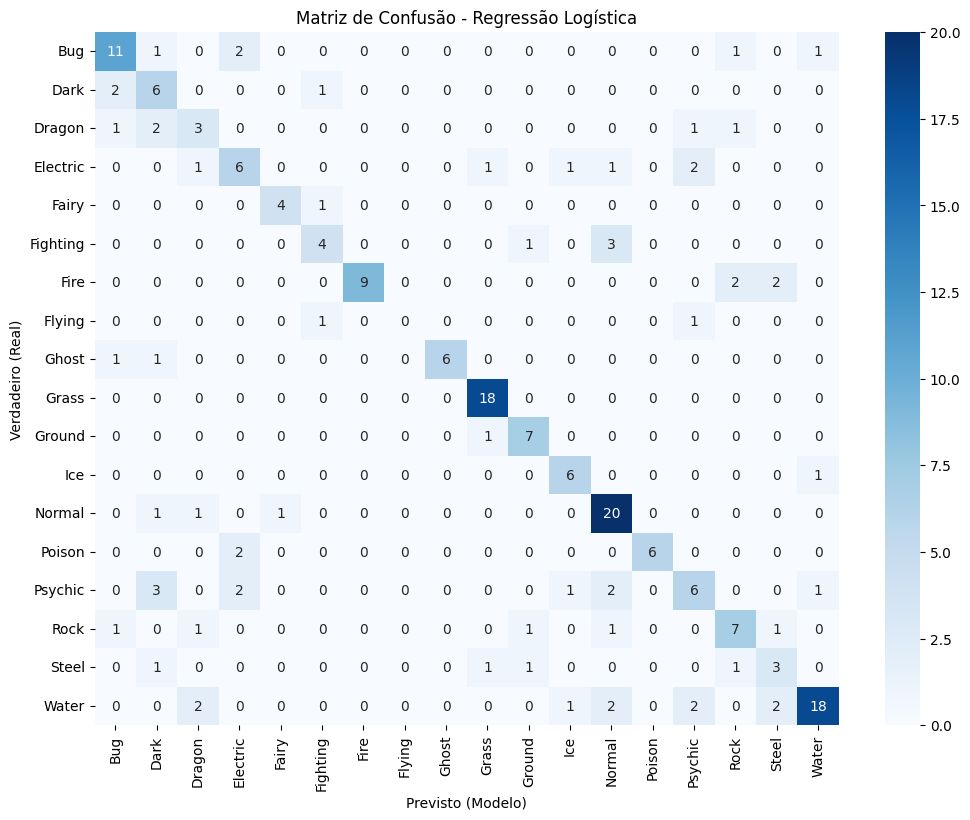


--- Principais Features para: Regressão Logística ---
ohe_categorical__type_2_Psychic              0.725492
ohe_categorical__ability_1_Levitate          0.628640
ohe_categorical__ability_1_Beast Boost       0.620498
ohe_categorical__type_2_Water                0.608733
ohe_categorical__type_2_Dragon               0.590592
ohe_categorical__growth_rate_Slow            0.578919
ohe_categorical__type_2_Ghost                0.575458
ohe_categorical__ability_hidden_Telepathy    0.557860
power_transform_numerical__weight_kg         0.549059
ohe_categorical__type_2_Fighting             0.548909
ohe_categorical__ability_1_Keen Eye          0.536315
power_transform_numerical__sp_attack         0.533101
ohe_categorical__growth_rate_Medium Slow     0.529164
ohe_categorical__type_2_Poison               0.519675
ohe_categorical__ability_hidden_Vazio        0.501262
dtype: float64

--- Lista de Erros para: Regressão Logística ---
Total de erros: 66 de 206 amostras de teste.
                        n

In [ ]:
name = "Regressão Logística"
model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

print(f"\n=======================================================")
print(f"--- Treinando e Avaliando: {name} ---")

# --- 2. Treinar ---
# (Se estiver usando SMOTE, use .fit(X_train_final, y_train_final))
model.fit(X_train_smote, y_train_smote)

# --- 3. Prever e Avaliar ---
y_pred = model.predict(X_test_transformed)

f1 = f1_score(y_test, y_pred, average='weighted')
print(f"F1-Score (Weighted): {f1:.4f}")
print(classification_report(y_test, y_pred, target_names=class_names, zero_division=0))

# --- 4. Matriz de Confusão ---
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(12, 9))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title(f'Matriz de Confusão - {name}')
plt.ylabel('Verdadeiro (Real)')
plt.xlabel('Previsto (Modelo)')
plt.xticks(rotation=90); plt.yticks(rotation=0)
plt.show()

# --- 5. Principais Features ---
print(f"\n--- Principais Features para: {name} ---")
if feature_names is not None:
    if hasattr(model, 'coef_'): # Para Regressão Logística
        # Para multiclasse, tiramos a média do valor absoluto dos coeficientes
        importances = np.mean(np.abs(model.coef_), axis=0)
        df_imp = pd.Series(importances, index=feature_names)
        print(df_imp.sort_values(ascending=False).head(15))
    else:
        print("Modelo não possui atributo .coef_")
else:
    print("Não foi possível extrair nomes das features do 'preprocessor'.")

# --- 6. Lista de Erros (Forma Corrigida) ---
print(f"\n--- Lista de Erros para: {name} ---")

# Converte os números de volta para texto (ex: 0 -> 'Water')
y_test_text = le.inverse_transform(y_test)
y_pred_text = le.inverse_transform(y_pred)

try:
    nomes_dos_pokemons_no_teste = df.loc[X_test.index, 'name']
except NameError:
    print("Erro: DataFrame 'df' original não encontrado para buscar os nomes.")
    nomes_dos_pokemons_no_teste = X_test.index # Usa o índice como fallback

# Cria o DataFrame de resultados
df_resultados = pd.DataFrame({
    'name': nomes_dos_pokemons_no_teste, # <-- MUDANÇA AQUI
    'type_1 (Real)': y_test_text,
    'type_1 (Previsto)': y_pred_text
})

# Filtra apenas pelas linhas onde o modelo errou
errors_df = df_resultados[df_resultados['type_1 (Real)'] != df_resultados['type_1 (Previsto)']].copy()

if len(errors_df) == 0:
    print("Nenhum erro encontrado neste modelo!")
else:
    print(f"Total de erros: {len(errors_df)} de {len(df_resultados)} amostras de teste.")
    print(errors_df.head(20))


print(f"\n--- PIORES (MENOS IMPORTANTES) FEATURES para: {name} ---")
# Pega as 15 features com a MENOR importância
print(df_imp.sort_values(ascending=True).head(15))

## Naive Bayes SMOTE


--- Treinando e Avaliando: Gaussian Naive Bayes ---
AVISO: Este modelo não tem 'class_weight'.
TREINANDO COM DADOS BALANCEADOS (SMOTE).
Convertendo dados para formato denso (necessário para Naive Bayes)...
F1-Score (Weighted): 0.6553
              precision    recall  f1-score   support

         Bug       0.91      0.62      0.74        16
        Dark       0.71      0.56      0.62         9
      Dragon       0.29      0.25      0.27         8
    Electric       1.00      0.58      0.74        12
       Fairy       0.50      1.00      0.67         5
    Fighting       0.33      0.50      0.40         8
        Fire       0.90      0.69      0.78        13
      Flying       0.17      0.50      0.25         2
       Ghost       0.35      0.88      0.50         8
       Grass       1.00      0.94      0.97        18
      Ground       1.00      0.75      0.86         8
         Ice       0.75      0.86      0.80         7
      Normal       0.70      0.61      0.65        23
      Po

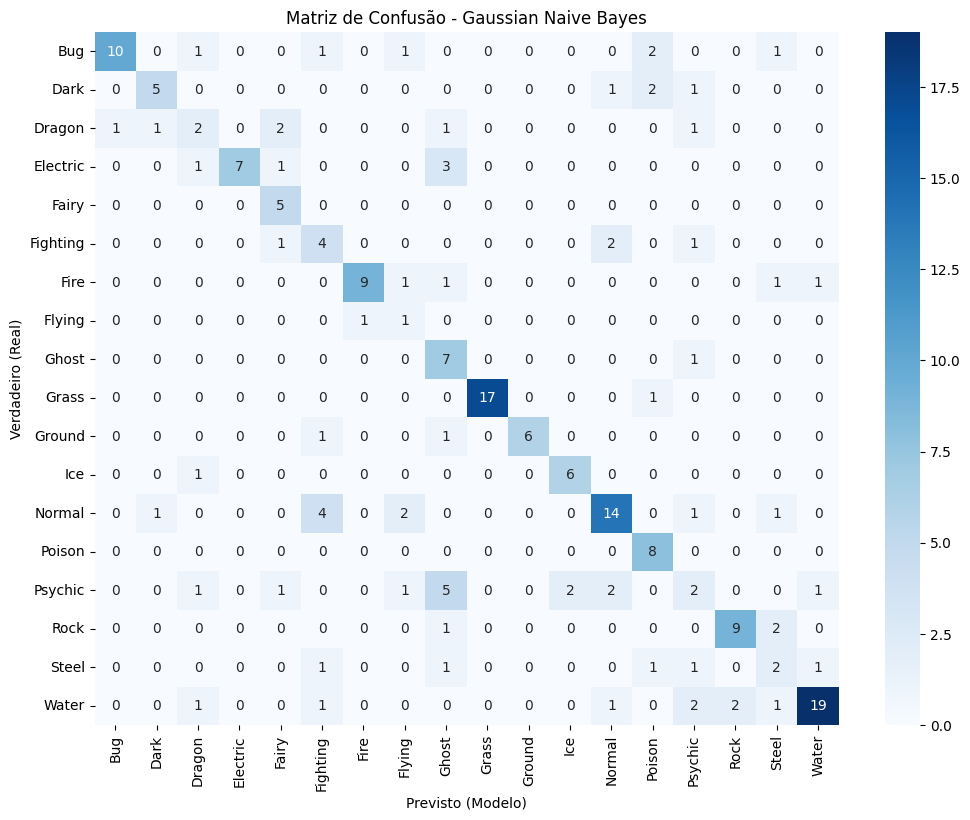


--- Principais Features para: Gaussian Naive Bayes ---
O modelo Gaussian Naive Bayes não fornece uma lista de 'feature importance' simples.
A importância é inferida pela média (theta_) de cada feature por classe.

--- Lista de Erros para: Gaussian Naive Bayes ---
Total de erros: 73 de 206 amostras de teste.
                    name type_1 (Real) type_1 (Previsto)
956             Orbeetle           Bug          Fighting
840            Volcanion          Fire            Flying
965               Yamper      Electric             Fairy
148      Mega Kangaskhan        Normal            Flying
893               Wimpod           Bug            Flying
256              Shuckle           Bug             Steel
903           Turtonator          Fire             Water
102    Galarian Rapidash       Psychic            Normal
14               Metapod           Bug            Poison
784               Espurr       Psychic            Flying
977          Barraskewda         Water              Rock
891   

In [ ]:
from sklearn.naive_bayes import GaussianNB

name = "Gaussian Naive Bayes"
model = GaussianNB()

print(f"\n=======================================================")
print(f"--- Treinando e Avaliando: {name} ---")
print("AVISO: Este modelo não tem 'class_weight'.")
print("TREINANDO COM DADOS BALANCEADOS (SMOTE).")

# --- 2. Treinar ---
print("Convertendo dados para formato denso (necessário para Naive Bayes)...")

# Converte o X de treino para denso

model.fit(X_train_smote.toarray(), y_train_smote)

# --- 3. Prever e Avaliar ---
y_pred = model.predict(X_test_transformed.toarray())
f1 = f1_score(y_test, y_pred, average='weighted')
print(f"F1-Score (Weighted): {f1:.4f}")
print(classification_report(y_test, y_pred, target_names=class_names, zero_division=0))

# --- 4. Matriz de Confusão ---
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(12, 9))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title(f'Matriz de Confusão - {name}')
plt.ylabel('Verdadeiro (Real)')
plt.xlabel('Previsto (Modelo)')
plt.xticks(rotation=90); plt.yticks(rotation=0)
plt.show()

# --- 5. Principais Features ---
print(f"\n--- Principais Features para: {name} ---")

print(f"O modelo {name} não fornece uma lista de 'feature importance' simples.")
print("A importância é inferida pela média (theta_) de cada feature por classe.")

# --- 6. Lista de Erros (Forma Corrigida) ---
print(f"\n--- Lista de Erros para: {name} ---")

# Converte os números de volta para texto (ex: 0 -> 'Water')
y_test_text = le.inverse_transform(y_test)
y_pred_text = le.inverse_transform(y_pred)

try:
    nomes_dos_pokemons_no_teste = df.loc[X_test.index, 'name']
except NameError:
    print("Erro: DataFrame 'df' original não encontrado para buscar os nomes.")
    nomes_dos_pokemons_no_teste = X_test.index

# Cria o DataFrame de resultados
df_resultados = pd.DataFrame({
    'name': nomes_dos_pokemons_no_teste,
    'type_1 (Real)': y_test_text,
    'type_1 (Previsto)': y_pred_text
})

# Filtra apenas pelas linhas onde o modelo errou
errors_df = df_resultados[df_resultados['type_1 (Real)'] != df_resultados['type_1 (Previsto)']].copy()

if len(errors_df) == 0:
    print("Nenhum erro encontrado neste modelo!")
else:
    print(f"Total de erros: {len(errors_df)} de {len(df_resultados)} amostras de teste.")
    print(errors_df.head(20))


print(f"\n--- PIORES (MENOS IMPORTANTES) FEATURES para: {name} ---")
# Pega as 15 features com a MENOR importância
print(df_imp.sort_values(ascending=True).head(15))

##SVM SMOTE


--- Treinando e Avaliando: SVM (Support Vector Classifier) ---
AVISO: Este modelo não tem 'class_weight'.
TREINANDO COM DADOS BALANCEADOS (SMOTE).
F1-Score (Weighted): 0.5102
              precision    recall  f1-score   support

         Bug       0.57      0.50      0.53        16
        Dark       0.39      0.78      0.52         9
      Dragon       0.56      0.62      0.59         8
    Electric       0.39      0.58      0.47        12
       Fairy       0.60      0.60      0.60         5
    Fighting       0.33      0.38      0.35         8
        Fire       0.88      0.54      0.67        13
      Flying       0.00      0.00      0.00         2
       Ghost       0.83      0.62      0.71         8
       Grass       0.67      0.78      0.72        18
      Ground       0.50      0.38      0.43         8
         Ice       0.50      0.14      0.22         7
      Normal       0.56      0.65      0.60        23
      Poison       0.50      0.12      0.20         8
     Psychic 

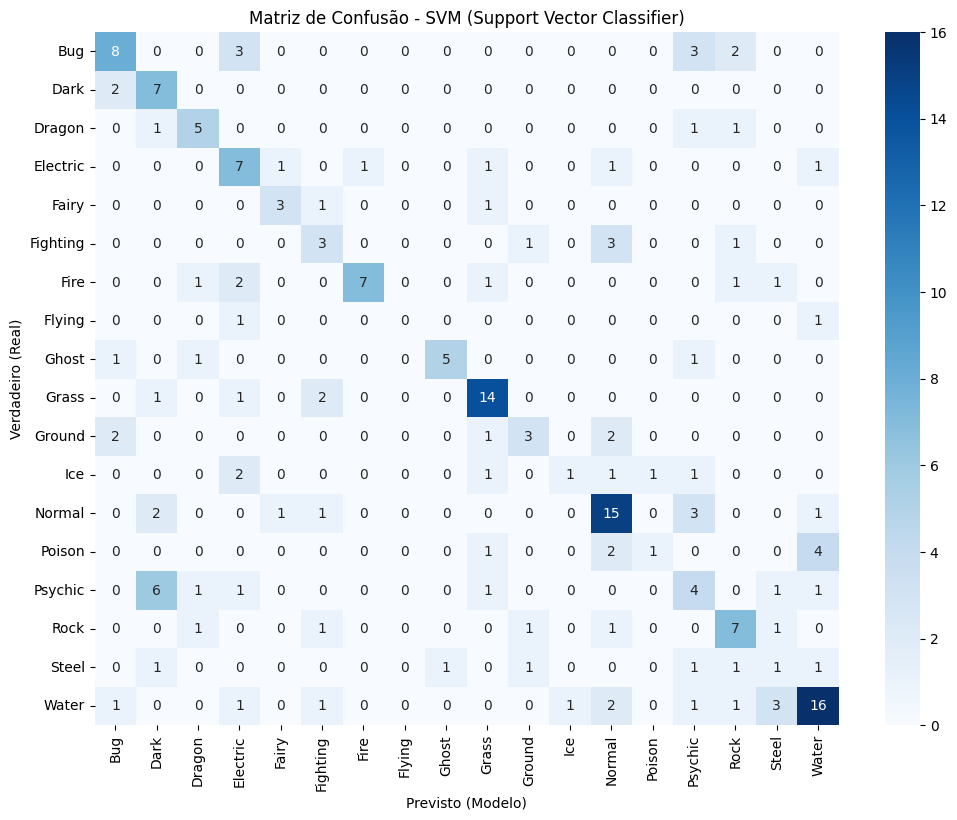


--- Principais Features para: SVM (Support Vector Classifier) ---
O modelo SVM (Support Vector Classifier) (com kernel 'rbf') não fornece feature importance direta.

--- Lista de Erros para: SVM (Support Vector Classifier) ---
Total de erros: 99 de 206 amostras de teste.
                        name type_1 (Real) type_1 (Previsto)
30                     Ekans        Poison            Normal
956                 Orbeetle           Bug           Psychic
840                Volcanion          Fire            Dragon
372                 Illumise           Bug           Psychic
965                   Yamper      Electric             Fairy
950                 Greedent        Normal             Fairy
148          Mega Kangaskhan        Normal          Fighting
140                  Koffing        Poison             Grass
256                  Shuckle           Bug           Psychic
903               Turtonator          Fire             Steel
781                  Pancham      Fighting            No

In [ ]:
from sklearn.svm import SVC

name = "SVM (Support Vector Classifier)"
model = SVC(
    random_state=42,
    probability=True
    )

print(f"\n=======================================================")
print(f"--- Treinando e Avaliando: {name} ---")
print("AVISO: Este modelo não tem 'class_weight'.")
print("TREINANDO COM DADOS BALANCEADOS (SMOTE).")

# --- 2. Treinar ---
model.fit(X_train_smote, y_train_smote)

# --- 3. Prever e Avaliar ---
y_pred = model.predict(X_test_transformed)

f1 = f1_score(y_test, y_pred, average='weighted')
print(f"F1-Score (Weighted): {f1:.4f}")
print(classification_report(y_test, y_pred, target_names=class_names, zero_division=0))

# --- 4. Matriz de Confusão ---
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(12, 9))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title(f'Matriz de Confusão - {name}')
plt.ylabel('Verdadeiro (Real)')
plt.xlabel('Previsto (Modelo)')
plt.xticks(rotation=90); plt.yticks(rotation=0)
plt.show()

# --- 5. Principais Features ---
print(f"\n--- Principais Features para: {name} ---")
print(f"O modelo {name} (com kernel 'rbf') não fornece feature importance direta.")

# --- 6. Lista de Erros (Forma Corrigida) ---
print(f"\n--- Lista de Erros para: {name} ---")

# Converte os números de volta para texto (ex: 0 -> 'Water')
y_test_text = le.inverse_transform(y_test)
y_pred_text = le.inverse_transform(y_pred)

try:
    nomes_dos_pokemons_no_teste = df.loc[X_test.index, 'name']
except NameError:
    print("Erro: DataFrame 'df' original não encontrado para buscar os nomes.")
    nomes_dos_pokemons_no_teste = X_test.index
# Cria o DataFrame de resultados
df_resultados = pd.DataFrame({
    'name': nomes_dos_pokemons_no_teste,
    'type_1 (Real)': y_test_text,
    'type_1 (Previsto)': y_pred_text
})

# Filtra apenas pelas linhas onde o modelo errou
errors_df = df_resultados[df_resultados['type_1 (Real)'] != df_resultados['type_1 (Previsto)']].copy()

if len(errors_df) == 0:
    print("Nenhum erro encontrado neste modelo!")
else:
    print(f"Total de erros: {len(errors_df)} de {len(df_resultados)} amostras de teste.")
    print(errors_df.head(20))

##GridSearch Regression (Best Model)

--- Iniciando Otimização (GridSearch) para Regressão Logística ---
AVISO: Usando dados do SMOTE (X_train_smote), 'class_weight' não é necessário.
Fitting 5 folds for each of 20 candidates, totalling 100 fits


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning:

'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge




--- Otimização Concluída ---
Melhor F1-Score (em validação cruzada): 0.9334
Melhores Hiperparâmetros encontrados:
{'C': 100, 'multi_class': 'ovr', 'penalty': 'l1'}

--- Avaliação Final: Regressão Logística (Otimizada) ---
F1-Score (Weighted) no CONJUNTO DE TESTE: 0.7222
              precision    recall  f1-score   support

         Bug       0.75      0.75      0.75        16
        Dark       0.60      0.67      0.63         9
      Dragon       0.40      0.25      0.31         8
    Electric       0.56      0.75      0.64        12
       Fairy       0.80      0.80      0.80         5
    Fighting       0.71      0.62      0.67         8
        Fire       0.83      0.77      0.80        13
      Flying       0.00      0.00      0.00         2
       Ghost       0.78      0.88      0.82         8
       Grass       0.86      1.00      0.92        18
      Ground       0.64      0.88      0.74         8
         Ice       0.75      0.86      0.80         7
      Normal       0.72  

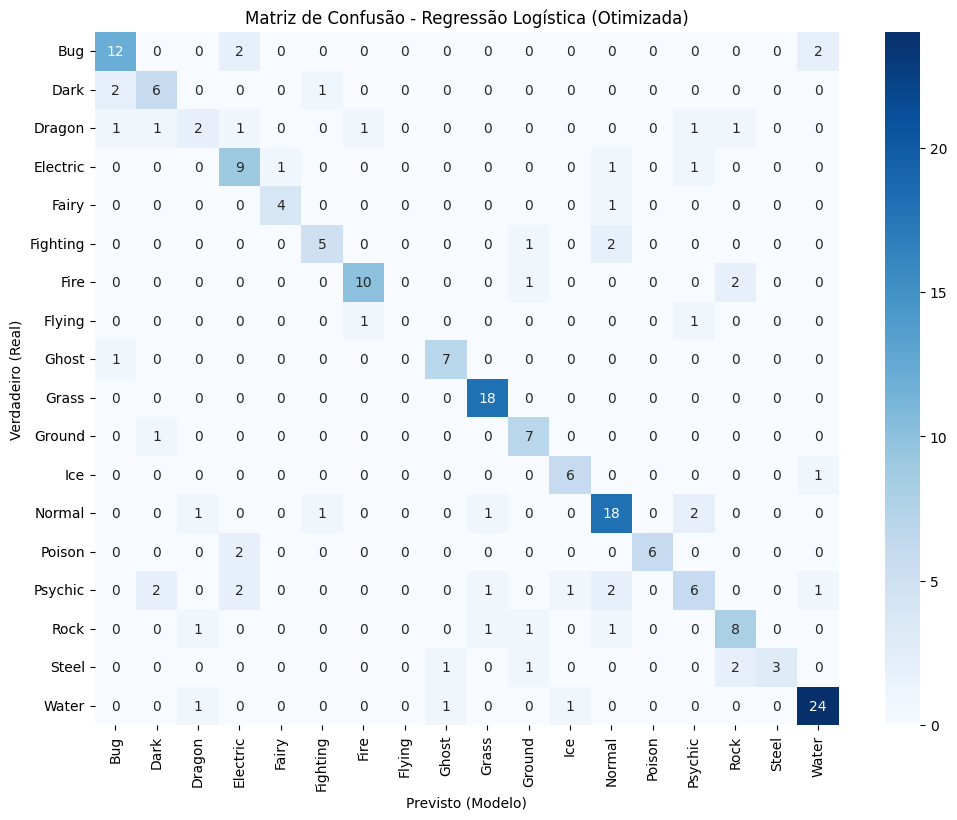


--- Principais Features para: Regressão Logística (Otimizada) ---
ohe_categorical__type_2_Vazio                  7.163279
ohe_categorical__ability_2_Vazio               6.144549
power_transform_numerical__abilities_number    4.282107
ohe_categorical__ability_1_Beast Boost         3.819897
power_transform_numerical__type_number         3.505190
ohe_categorical__growth_rate_Fast              3.452582
power_transform_numerical__total_points        3.219097
ohe_categorical__growth_rate_Medium Slow       3.178901
ohe_categorical__growth_rate_Slow              3.153957
ohe_categorical__type_2_Dragon                 3.052072
ohe_categorical__type_2_Psychic                2.824890
ohe_categorical__ability_1_Levitate            2.718236
ohe_categorical__growth_rate_Medium Fast       2.692486
ohe_categorical__ability_hidden_Vazio          2.683401
ohe_categorical__type_2_Poison                 2.564177
dtype: float64

--- Lista de Erros para: Regressão Logística (Otimizada) ---
Total de erros: 

In [ ]:
from sklearn.model_selection import GridSearchCV

print("--- Iniciando Otimização (GridSearch) para Regressão Logística ---")
print("AVISO: Usando dados do SMOTE (X_train_smote), 'class_weight' não é necessário.")

base_lr = LogisticRegression(
    solver='saga',
    random_state=42,
    max_iter=3000
)

param_grid_lr = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'multi_class': ['ovr', 'multinomial']
}

# --- 2. Configurar o GridSearchCV ---
grid_lr = GridSearchCV(
    estimator=base_lr,
    param_grid=param_grid_lr,
    scoring='f1_weighted',
    cv=5,
    verbose=2,
    n_jobs=-1
)

# --- 3. Executar o Treinamento do Grid ---
grid_lr.fit(X_train_smote, y_train_smote)

# --- 4. Exibir os Melhores Resultados ---
print("\n--- Otimização Concluída ---")
print(f"Melhor F1-Score (em validação cruzada): {grid_lr.best_score_:.4f}")
print(f"Melhores Hiperparâmetros encontrados:")
print(grid_lr.best_params_)

# --- 5. Análise Completa do MELHOR Modelo ---
best_lr_model = grid_lr.best_estimator_
name = "Regressão Logística (Otimizada)"

print(f"\n=======================================================")
print(f"--- Avaliação Final: {name} ---")

# --- 6. Prever e Avaliar no Teste ---
y_pred = best_lr_model.predict(X_test_transformed)

f1 = f1_score(y_test, y_pred, average='weighted')
print(f"F1-Score (Weighted) no CONJUNTO DE TESTE: {f1:.4f}")
print(classification_report(y_test, y_pred, target_names=class_names, zero_division=0))

# --- 7. Matriz de Confusão ---
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(12, 9))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title(f'Matriz de Confusão - {name}')
plt.ylabel('Verdadeiro (Real)')
plt.xlabel('Previsto (Modelo)')
plt.xticks(rotation=90); plt.yticks(rotation=0)
plt.show()

# --- 8. Principais Features ---
print(f"\n--- Principais Features para: {name} ---")
if feature_names is not None:
    if hasattr(best_lr_model, 'coef_'):
      importances = np.mean(np.abs(best_lr_model.coef_), axis=0)
      df_imp = pd.Series(importances, index=feature_names)
      print(df_imp.sort_values(ascending=False).head(15))
    else:
        print("Modelo não possui atributo .coef_")
else:
    print("Não foi possível extrair nomes das features do 'preprocessor'.")

# --- 9. Lista de Erros ---
print(f"\n--- Lista de Erros para: {name} ---")

# Converte os números de volta para texto (ex: 0 -> 'Water')
y_test_text = le.inverse_transform(y_test)
y_pred_text = le.inverse_transform(y_pred)

try:
    nomes_dos_pokemons_no_teste = df.loc[X_test.index, 'name']
except NameError:
    print("Erro: DataFrame 'df' original não encontrado para buscar os nomes.")
    nomes_dos_pokemons_no_teste = X_test.index
except KeyError:
    print("Erro: A coluna 'name' não foi encontrada no 'df' original.")
    nomes_dos_pokemons_no_teste = X_test.index

# Cria o DataFrame de resultados
df_resultados = pd.DataFrame({
    'name': nomes_dos_pokemons_no_teste,
    'type_1 (Real)': y_test_text,
    'type_1 (Previsto)': y_pred_text
})

# Filtra apenas pelas linhas onde o modelo errou
errors_df = df_resultados[df_resultados['type_1 (Real)'] != df_resultados['type_1 (Previsto)']].copy()

if len(errors_df) == 0:
    print("Nenhum erro encontrado neste modelo!")
else:
    print(f"Total de erros: {len(errors_df)} de {len(df_resultados)} amostras de teste.")
    print(errors_df.head(20))

##GridSearch MLP (Best Model)


--- Treinando e Avaliando: MLP (Rede Neural) ---
AVISO: Este modelo não tem 'class_weight'.
TREINANDO COM DADOS BALANCEADOS (SMOTE).
F1-Score (Weighted): 0.6739
              precision    recall  f1-score   support

         Bug       0.76      0.81      0.79        16
        Dark       0.67      0.67      0.67         9
      Dragon       0.33      0.25      0.29         8
    Electric       0.67      0.67      0.67        12
       Fairy       0.67      0.80      0.73         5
    Fighting       0.50      0.62      0.56         8
        Fire       1.00      0.69      0.82        13
      Flying       0.00      0.00      0.00         2
       Ghost       0.75      0.75      0.75         8
       Grass       0.82      1.00      0.90        18
      Ground       0.58      0.88      0.70         8
         Ice       0.75      0.86      0.80         7
      Normal       0.69      0.78      0.73        23
      Poison       0.86      0.75      0.80         8
     Psychic       0.33    

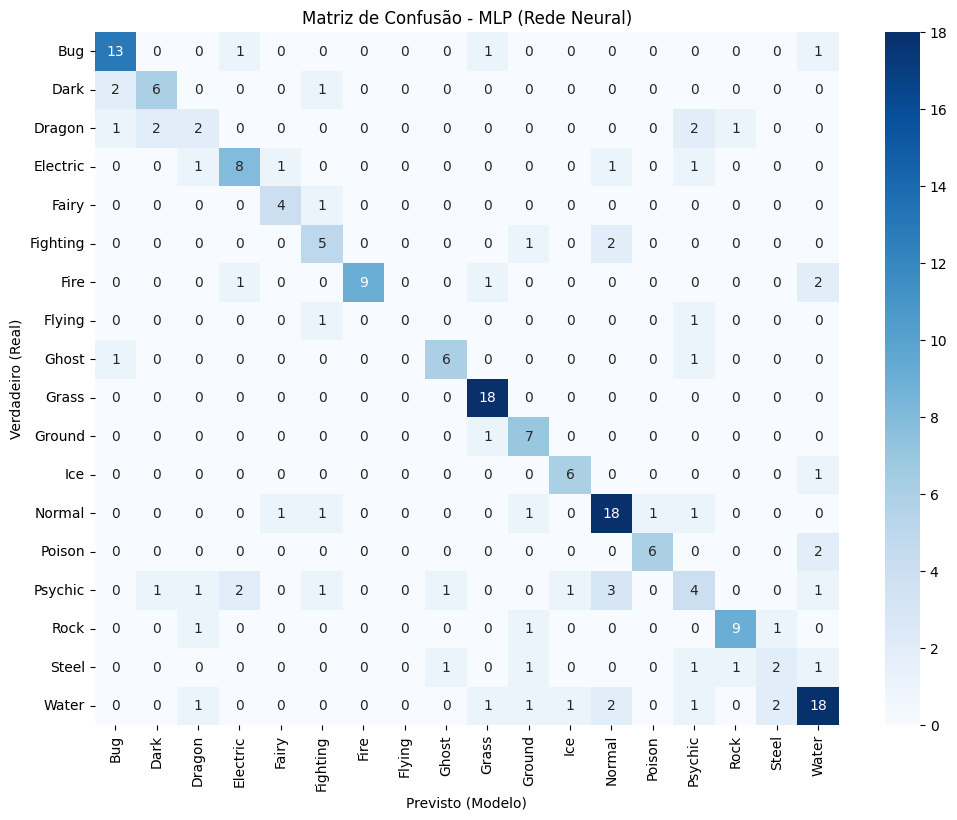


--- Principais Features para: MLP (Rede Neural) ---
O modelo MLP (Rede Neural) não fornece feature importance direta.

--- Lista de Erros para: MLP (Rede Neural) ---
Total de erros: 65 de 206 amostras de teste.
                      name type_1 (Real) type_1 (Previsto)
840              Volcanion          Fire             Water
372               Illumise           Bug             Water
965                 Yamper      Electric             Fairy
148        Mega Kangaskhan        Normal          Fighting
140                Koffing        Poison             Water
256                Shuckle           Bug             Grass
903             Turtonator          Fire             Water
1022  Zacian Crowned Sword         Fairy          Fighting
102      Galarian Rapidash       Psychic            Normal
891               Oranguru        Normal            Poison
441         Mega Salamence        Dragon               Bug
993              Obstagoon          Dark          Fighting
748                 K

In [ ]:
from sklearn.neural_network import MLPClassifier

# --- 1. Definir o Modelo ---
name = "MLP (Rede Neural)"
model = MLPClassifier(
    random_state=42,
    hidden_layer_sizes=(100, 50),
    max_iter=1000,
    early_stopping=True,
    n_iter_no_change=10
)

print(f"\n=======================================================")
print(f"--- Treinando e Avaliando: {name} ---")
print("AVISO: Este modelo não tem 'class_weight'.")
print("TREINANDO COM DADOS BALANCEADOS (SMOTE).")

# --- 2. Treinar ---
model.fit(X_train_smote, y_train_smote)

# --- 3. Prever e Avaliar ---
y_pred = model.predict(X_test_transformed)

f1 = f1_score(y_test, y_pred, average='weighted')
print(f"F1-Score (Weighted): {f1:.4f}")
print(classification_report(y_test, y_pred, target_names=class_names, zero_division=0))

# --- 4. Matriz de Confusão ---
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(12, 9))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title(f'Matriz de Confusão - {name}')
plt.ylabel('Verdadeiro (Real)')
plt.xlabel('Previsto (Modelo)')
plt.xticks(rotation=90); plt.yticks(rotation=0)
plt.show()

# --- 5. Principais Features ---
print(f"\n--- Principais Features para: {name} ---")
print(f"O modelo {name} não fornece feature importance direta.")

# --- 6. Lista de Erros (Corrigido) ---
print(f"\n--- Lista de Erros para: {name} ---")
y_test_text = le.inverse_transform(y_test)
y_pred_text = le.inverse_transform(y_pred)

try:
  nomes_dos_pokemons_no_teste = df.loc[X_test.index, 'name']
except NameError:
  print("Erro: DataFrame 'df' original não encontrado para buscar os nomes.")
  nomes_dos_pokemons_no_teste = X_test.index
except KeyError:
  print("Erro: A coluna 'name' não foi encontrada no 'df' original.")
  nomes_dos_pokemons_no_teste = X_test.index

# Cria o DataFrame de resultados
df_resultados = pd.DataFrame({
    'name': nomes_dos_pokemons_no_teste,
    'type_1 (Real)': y_test_text,
    'type_1 (Previsto)': y_pred_text
})

# Filtra apenas pelas linhas onde o modelo errou
errors_df = df_resultados[df_resultados['type_1 (Real)'] != df_resultados['type_1 (Previsto)']].copy()

if len(errors_df) == 0:
    print("Nenhum erro encontrado neste modelo!")
else:
    print(f"Total de erros: {len(errors_df)} de {len(df_resultados)} amostras de teste.")
    print(errors_df.head(20))


--- Iniciando Otimização (GridSearch) para: MLP (Rede Neural) ---
AVISO: Usando dados do SMOTE (X_train_smote).
AVISO 2: Este processo será EXTREMAMENTE LENTO (30-60+ minutos).
Fitting 5 folds for each of 30 candidates, totalling 150 fits

--- Otimização Concluída ---
Melhor F1-Score (em validação cruzada): 0.9216
Melhores Hiperparâmetros encontrados:
{'activation': 'tanh', 'alpha': 0.0001, 'hidden_layer_sizes': (150,)}

--- Avaliação Final: MLP (Otimizado) ---
F1-Score (Weighted) no CONJUNTO DE TESTE: 0.6824
              precision    recall  f1-score   support

         Bug       0.67      0.75      0.71        16
        Dark       0.38      0.67      0.48         9
      Dragon       0.43      0.38      0.40         8
    Electric       0.70      0.58      0.64        12
       Fairy       0.67      0.80      0.73         5
    Fighting       0.56      0.62      0.59         8
        Fire       0.80      0.62      0.70        13
      Flying       0.00      0.00      0.00        

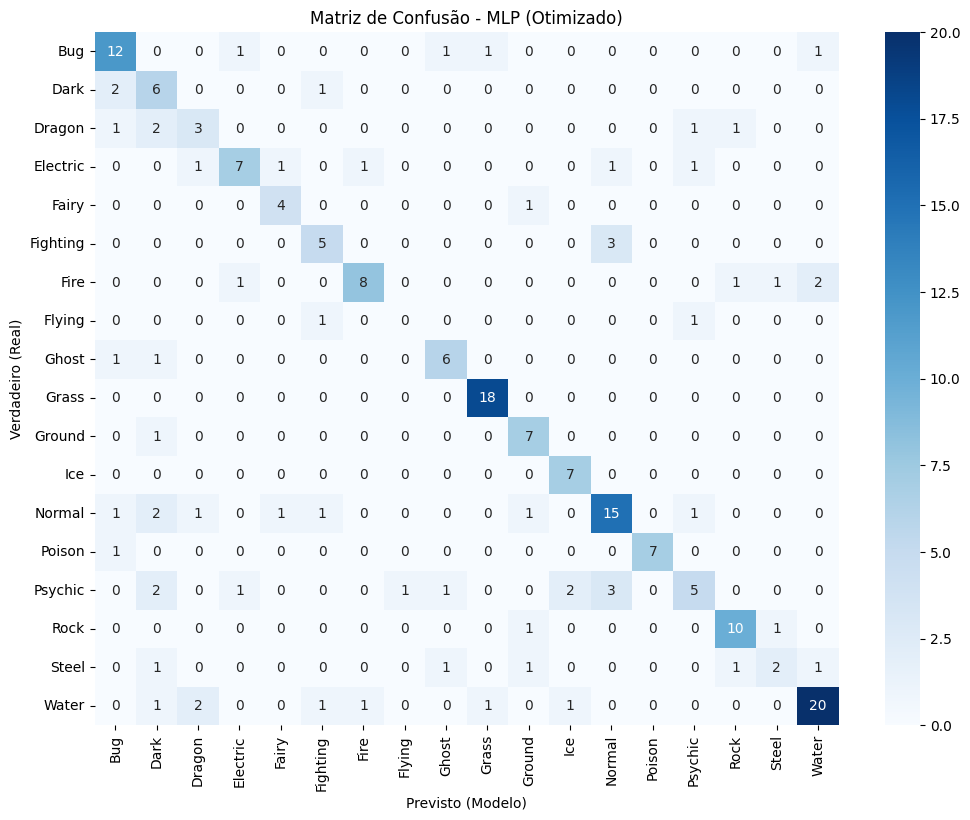


--- Principais Features para: MLP (Otimizado) ---
O modelo MLP (Otimizado) não fornece feature importance direta.

--- Lista de Erros para: MLP (Otimizado) ---
Total de erros: 64 de 206 amostras de teste.
                      name type_1 (Real) type_1 (Previsto)
30                   Ekans        Poison               Bug
956               Orbeetle           Bug             Ghost
840              Volcanion          Fire             Water
372               Illumise           Bug             Water
965                 Yamper      Electric             Fairy
256                Shuckle           Bug             Grass
903             Turtonator          Fire             Water
781                Pancham      Fighting            Normal
1022  Zacian Crowned Sword         Fairy            Ground
102      Galarian Rapidash       Psychic            Normal
784                 Espurr       Psychic            Flying
891               Oranguru        Normal            Dragon
441         Mega Salamence 

In [ ]:
print(f"\n=======================================================")
print(f"--- Iniciando Otimização (GridSearch) para: MLP (Rede Neural) ---")
print("AVISO: Usando dados do SMOTE (X_train_smote).")
print("AVISO 2: Este processo será EXTREMAMENTE LENTO (30-60+ minutos).")

# Modelo base
base_mlp = MLPClassifier(
    random_state=42,
    max_iter=100,                 # Máximo de épocas
    early_stopping=True,          # Para o treino se não melhorar
    n_iter_no_change=10
)

# Grid de parâmetros para testar
# (É um grid pequeno para economizar tempo)
param_grid_mlp = {
    'hidden_layer_sizes': [
        (100,),
        (100, 50),
        (50, 50),
        (100, 100),
        (150,)
    ],
    'activation': ['relu', 'tanh'], # Testa as duas ativações
    'alpha': [0.0001, 0.001, 0.01]   # Testa 3 níveis de regularização (L2)
}

# --- 2. Configurar o GridSearchCV ---
grid_mlp = GridSearchCV(
    estimator=base_mlp,
    param_grid=param_grid_mlp,
    scoring='f1_weighted',
    cv=5,      # 5 folds
    verbose=2, # Mostra o progresso
    n_jobs=-1  # Usa todos os processadores
)

# --- 3. Executar o Treinamento do Grid (Parte LENTA) ---
grid_mlp.fit(X_train_smote, y_train_smote)

# --- 4. Exibir os Melhores Resultados ---
print("\n--- Otimização Concluída ---")
print(f"Melhor F1-Score (em validação cruzada): {grid_mlp.best_score_:.4f}")
print(f"Melhores Hiperparâmetros encontrados:")
print(grid_mlp.best_params_)

# --- 5. Análise Completa do MELHOR Modelo ---
best_mlp_model = grid_mlp.best_estimator_
name = "MLP (Otimizado)"

print(f"\n=======================================================")
print(f"--- Avaliação Final: {name} ---")

# --- 6. Prever e Avaliar no Teste ---
y_pred = best_mlp_model.predict(X_test_transformed)

f1 = f1_score(y_test, y_pred, average='weighted')
print(f"F1-Score (Weighted) no CONJUNTO DE TESTE: {f1:.4f}")
print(classification_report(y_test, y_pred, target_names=class_names, zero_division=0))

# --- 7. Matriz de Confusão ---
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(12, 9))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title(f'Matriz de Confusão - {name}')
plt.ylabel('Verdadeiro (Real)')
plt.xlabel('Previsto (Modelo)')
plt.xticks(rotation=90); plt.yticks(rotation=0)
plt.show()

# --- 8. Principais Features ---
print(f"\n--- Principais Features para: {name} ---")
print(f"O modelo {name} não fornece feature importance direta.")

# --- 9. Lista de Erros (Corrigido) ---
print(f"\n--- Lista de Erros para: {name} ---")
y_test_text = le.inverse_transform(y_test)
y_pred_text = le.inverse_transform(y_pred)

try:
    # Busca o 'name' no DataFrame original 'df' usando o índice do 'X_test'
    nomes_dos_pokemons_no_teste = df.loc[X_test.index, 'name']
except NameError:
    print("Erro: DataFrame 'df' original não encontrado para buscar os nomes.")
    nomes_dos_pokemons_no_teste = X_test.index
except KeyError:
    print("Erro: A coluna 'name' não foi encontrada no 'df' original.")
    nomes_dos_pokemons_no_teste = X_test.index

# Cria o DataFrame de resultados
df_resultados = pd.DataFrame({
    'name': nomes_dos_pokemons_no_teste,
    'type_1 (Real)': y_test_text,
    'type_1 (Previsto)': y_pred_text
})

# Filtra apenas pelas linhas onde o modelo errou
errors_df = df_resultados[df_resultados['type_1 (Real)'] != df_resultados['type_1 (Previsto)']].copy()

if len(errors_df) == 0:
    print("Nenhum erro encontrado neste modelo!")
else:
    print(f"Total de erros: {len(errors_df)} de {len(df_resultados)} amostras de teste.")
    print(errors_df.head(20))